# derived_8.4-regime-interpretation-1.2-oos — Out-of-State Regime Distribution & Environmental Interpretation

This experiment evaluates the **generalization of the 5 two-regime routing strategies** (`Clustering_V0_Full_k2`, `Clustering_Dynamic_k2`, `Seasonal_Binary_k2`, `Univariate_G_API_k2`, `Trained_Gating_k2`) from `derived_8.4-eval-1.1` on the **10 out-of-state held-out stations** (`derived_8.4-oos`).

- **Router Fitting**: The routers are fitted **strictly on the 7 Washington State stations** from `derived_8.4` (`trainval`, 2017–2022, 14,608 rows).
- **Evaluation**: The out-of-state dataset `derived_8.4-oos` (25,176 rows across 2017–2025 for 10 stations across OR, ID, CA, CO, WY, MT) is treated as a **completely held-out test set** to inspect regime assignment, station purity, dynamic weather drivers, static environmental attributes, and physical clustering behavior across the Western US.


In [1]:
"""Setup: reproduce the eval-1.1 routers for all five k2 strategies on derived_8.4, and evaluate on derived_8.4-oos."""
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

PROJECT_ROOT = Path("../../..").resolve()
SPLIT_DIR_WA = PROJECT_ROOT / "data" / "splits" / "derived_8.4"
SPLIT_DIR_OOS = PROJECT_ROOT / "data" / "splits" / "derived_8.4-oos"
EVAL_DIR = PROJECT_ROOT / "notebooks" / "experiment" / "derived_8.4-eval-1.1"
EXP_DIR = Path(".").resolve()


# --- Load splits (same preparation as eval-1.1 eval11/data.py) ---
def load_frame(path: Path) -> pd.DataFrame:
    base = pd.read_csv(path)
    dates = pd.to_datetime(base["date"], errors="raise")
    derived = pd.DataFrame(
        {"date": dates, "month": dates.dt.month.astype(int), "year": dates.dt.year.astype(int)}
    )
    # splits already contain a raw "year" column; drop it to avoid duplicates
    return pd.concat([base.drop(columns=["date", "month", "year"], errors="ignore"), derived], axis=1)


train_wa = load_frame(SPLIT_DIR_WA / "train.csv")
val_wa = load_frame(SPLIT_DIR_WA / "val.csv")
test_wa = load_frame(SPLIT_DIR_WA / "test.csv")
trainval_wa = pd.concat([train_wa, val_wa], axis=0, ignore_index=True)

# Out-of-state held-out dataset
oos_train = load_frame(SPLIT_DIR_OOS / "train.csv")
oos_val = load_frame(SPLIT_DIR_OOS / "val.csv")
oos_test = load_frame(SPLIT_DIR_OOS / "test.csv")
oos_all = pd.concat([oos_train, oos_val, oos_test], axis=0, ignore_index=True)

# Aliases for consistent downstream evaluation
trainval = trainval_wa
test = oos_all
test_wa_ref = test_wa

# --- Load the 50 V0 features from dataset metadata ---
spec = importlib.util.spec_from_file_location("dataset_metadata", SPLIT_DIR_WA / "dataset_metadata.py")
metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(metadata)
V0_FEATURES = list(metadata.OVERALL_SELECTED_FEATURES_V0)
TARGET = "soil_moisture_5cm"

# --- Import the exact router classes used by eval-1.1 ---
sys.path.insert(0, str(EVAL_DIR))
from eval11.routers import (  # noqa: E402
    DynamicClusterRouter,
    SeasonalBinaryRouter,
    TrainedGatingRouter,
    UnivariateGAPIRouter,
    V0FullRouter,
)

ROUTER_FACTORIES = {
    "Clustering_V0_Full_k2": lambda: V0FullRouter(V0_FEATURES, seed=42),
    "Clustering_Dynamic_k2": lambda: DynamicClusterRouter(seed=42),
    "Seasonal_Binary_k2": lambda: SeasonalBinaryRouter(),
    "Univariate_G_API_k2": lambda: UnivariateGAPIRouter(),
    "Trained_Gating_k2": lambda: TrainedGatingRouter(V0_FEATURES, seed=42, device="cpu"),
}

labels = {}
for strategy, factory in ROUTER_FACTORIES.items():
    router = factory()
    router.fit(trainval_wa)
    labels[(strategy, "trainval")] = router.predict(trainval_wa)
    labels[(strategy, "test_wa")] = router.predict(test_wa)
    labels[(strategy, "test")] = router.predict(oos_all)
    labels[(strategy, "oos_test_period")] = router.predict(oos_test)

print(f"WA trainval (fitted on): {len(trainval_wa)} rows (7 stations)")
print(f"WA test (in-sample check): {len(test_wa)} rows")
print(f"OOS held-out dataset: {len(oos_all)} rows (10 stations across 2017-2025)")
print(f"V0 features: {len(V0_FEATURES)}")
for strategy in ROUTER_FACTORIES:
    lt = labels[(strategy, "trainval")]
    lo = labels[(strategy, "test")]
    print(
        f"{strategy:24s} WA trainval 0 -> {int((lt == 0).sum())} ({float((lt == 0).mean()):.1%}), 1 -> {int((lt == 1).sum())} ({float((lt == 1).mean()):.1%})"
        f"  |  OOS 0 -> {int((lo == 0).sum())} ({float((lo == 0).mean()):.1%}), 1 -> {int((lo == 1).sum())} ({float((lo == 1).mean()):.1%})"
    )

WA trainval (fitted on): 14608 rows (7 stations)
WA test (in-sample check): 6620 rows
OOS held-out dataset: 25176 rows (10 stations across 2017-2025)
V0 features: 50
Clustering_V0_Full_k2    WA trainval 0 -> 10624 (72.7%), 1 -> 3984 (27.3%)  |  OOS 0 -> 6691 (26.6%), 1 -> 18485 (73.4%)
Clustering_Dynamic_k2    WA trainval 0 -> 7974 (54.6%), 1 -> 6634 (45.4%)  |  OOS 0 -> 19995 (79.4%), 1 -> 5181 (20.6%)
Seasonal_Binary_k2       WA trainval 0 -> 7559 (51.7%), 1 -> 7049 (48.3%)  |  OOS 0 -> 14579 (57.9%), 1 -> 10597 (42.1%)
Univariate_G_API_k2      WA trainval 0 -> 7304 (50.0%), 1 -> 7304 (50.0%)  |  OOS 0 -> 20066 (79.7%), 1 -> 5110 (20.3%)
Trained_Gating_k2        WA trainval 0 -> 4181 (28.6%), 1 -> 10427 (71.4%)  |  OOS 0 -> 11834 (47.0%), 1 -> 13342 (53.0%)


## 2. Sanity check against eval-1.1

We verify that fitting the routers on the 7 Washington stations reproduces the exact test labels of `derived_8.4-eval-1.1` on the Washington test set.

In [2]:
"""Sanity check: labels must match eval-1.1's saved test labels on the WA test split."""
EVAL_MODELS = EVAL_DIR / "models"
expected_files = {
    "Clustering_V0_Full_k2": "Clustering_V0_Full_k2_winner_labels_te.npy",
    "Clustering_Dynamic_k2": "Clustering_Dynamic_k2_winner_labels_te.npy",
    "Seasonal_Binary_k2": "Seasonal_Binary_k2_winner_labels_te.npy",
    "Univariate_G_API_k2": "Univariate_G_API_k2_winner_labels_te.npy",
    "Trained_Gating_k2": "Trained_Gating_k2_winner_labels_te.npy",
}

print("--- In-Sample Test-label agreement with eval-1.1 (models/*_winner_labels_te.npy) ---")
for strategy, fname in expected_files.items():
    expected = np.load(EVAL_MODELS / fname)
    got = labels[(strategy, "test_wa")]
    agree = float((expected == got).mean())
    n_match = int((expected == got).sum())
    print(f"{strategy:24s} agreement = {agree:.6f}  ({n_match}/{len(expected)} rows)")
    if strategy == "Trained_Gating_k2":
        assert agree >= 0.99, f"Trained_Gating_k2 agreement below 99%: {agree:.6f}"
    else:
        assert agree == 1.0, f"{strategy} labels differ from eval-1.1"

# Count check for the winning router on WA trainval
expected_counts = {"trainval": (10624, 3984)}
actual_counts = {
    "trainval": (
        int((labels[("Clustering_V0_Full_k2", "trainval")] == 0).sum()),
        int((labels[("Clustering_V0_Full_k2", "trainval")] == 1).sum()),
    )
}
for split_name, exp in expected_counts.items():
    got = actual_counts[split_name]
    status = "OK" if got == exp else "MISMATCH"
    print(f"{split_name:9s} expected {exp}  got {got}  -> {status}")
assert actual_counts == expected_counts, "V0-Full counts differ from eval-1.1"
print("All routers verified: 100% identical fitted logic to eval-1.1.")

--- In-Sample Test-label agreement with eval-1.1 (models/*_winner_labels_te.npy) ---
Clustering_V0_Full_k2    agreement = 1.000000  (6620/6620 rows)
Clustering_Dynamic_k2    agreement = 1.000000  (6620/6620 rows)
Seasonal_Binary_k2       agreement = 1.000000  (6620/6620 rows)
Univariate_G_API_k2      agreement = 1.000000  (6620/6620 rows)
Trained_Gating_k2        agreement = 0.996828  (6599/6620 rows)
trainval  expected (10624, 3984)  got (10624, 3984)  -> OK
All routers verified: 100% identical fitted logic to eval-1.1.


## 3. Per-strategy regime interpretation

We analyze what the two regimes represent across all five k2 routing strategies when applied to the held-out out-of-state stations.

In [3]:
"""Generalized per-regime interpretation for one k2 routing strategy evaluated on out-of-state stations."""
DRIVERS = ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR"]
STATIC_ATTRS = ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code"]


def rank_biserial(g0: pd.Series, g1: pd.Series) -> float:
    """Rank-biserial correlation r in [-1, +1]. Positive => cluster 1 has higher values."""
    s0 = g0.dropna()
    s1 = g1.dropna()
    if len(s0) == 0 or len(s1) == 0:
        return float("nan")
    stat, _ = mannwhitneyu(s1, s0, alternative="two-sided")
    u1 = float(stat)
    return float(2.0 * u1 / (len(s0) * len(s1)) - 1.0)


def interpret_regimes(strategy: str) -> None:
    print(f"\n{'=' * 78}\nStrategy: {strategy} (Evaluated on 10 Out-of-State Held-out Stations)\n{'=' * 78}")
    lbl_tr = labels[(strategy, "trainval")]
    lbl_te = labels[(strategy, "test")]
    clusters = sorted(np.unique(lbl_te))
    palette = {0: "#D95F02", 1: "#1B9E77"}

    # 1. Sizes
    n_tr, n_te = len(lbl_tr), len(lbl_te)
    print("\n--- Regime sizes ---")
    for c in clusters:
        cnt_tr, cnt_te = int((lbl_tr == c).sum()), int((lbl_te == c).sum())
        print(f"cluster {c}: WA trainval = {cnt_tr:5d} ({cnt_tr / n_tr:5.1%})  |  OOS held-out = {cnt_te:5d} ({cnt_te / n_te:5.1%})")

    # 2. Target distribution (soil_moisture_5cm)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (split_name, frame, lbl) in zip(axes, [("WA trainval (ref)", trainval, lbl_tr), ("OOS held-out test", test, lbl_te)]):
        for c in clusters:
            sns.kdeplot(frame.loc[lbl == c, TARGET], label=f"cluster {c}", color=palette[c], fill=True, alpha=0.35, ax=ax)
        ax.set_title(f"{split_name}: {TARGET} distribution ({strategy})")
        ax.set_xlabel(TARGET)
        ax.legend()
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_target_distributions_{strategy}.png", dpi=300)
    plt.show()

    # 3. Month of year (seasonality)
    season_rows = []
    for split_name, frame, lbl in [("WA trainval (ref)", trainval, lbl_tr), ("OOS held-out test", test, lbl_te)]:
        for m in range(1, 13):
            mask = frame["month"] == m
            n_m = int(mask.sum())
            if n_m == 0:
                continue
            for c in clusters:
                season_rows.append({"split": split_name, "month": m, "cluster": c,
                                    "share": int((lbl[mask] == c).sum()) / n_m})
    df_season = pd.DataFrame(season_rows)
    pivot_m = df_season.pivot_table(index="month", columns=["split", "cluster"], values="share")
    print("\n--- Share of each cluster per month ---")
    print(pivot_m.round(3).to_markdown())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, split_name in zip(axes, ["WA trainval (ref)", "OOS held-out test"]):
        sub = df_season[df_season["split"] == split_name]
        for c in clusters:
            part = sub[sub["cluster"] == c]
            ax.bar(part["month"], part["share"], color=palette[c], label=f"cluster {c}")
        ax.set_title(f"{split_name}: regime share by month ({strategy})")
        ax.set_ylabel("share")
        ax.legend()
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_seasonality_{strategy}.png", dpi=300)
    plt.show()

    # 4. Year composition
    year_rows = []
    for split_name, frame, lbl in [("WA trainval", trainval, lbl_tr), ("OOS held-out", test, lbl_te)]:
        for y in sorted(frame["year"].unique()):
            mask = frame["year"] == y
            n_y = int(mask.sum())
            for c in clusters:
                year_rows.append({"split": split_name, "year": int(y), "cluster": c,
                                  "share": int((lbl[mask] == c).sum()) / n_y})
    df_year = pd.DataFrame(year_rows)
    pivot_year = df_year.pivot_table(index="year", columns=["split", "cluster"], values="share")
    print("\n--- Share of each cluster per year ---")
    print(pivot_year.round(3).to_markdown())

    # 5. Station composition & purity on the OOS held-out dataset
    test_rows = []
    for sid, group in test.groupby("station_id"):
        mask = (test["station_id"] == sid).to_numpy()
        g_lbl = lbl_te[mask]
        n = len(group)
        shares = {c: float((g_lbl == c).mean()) for c in clusters}
        dominant = int(max(shares, key=shares.get))
        test_rows.append({
            "station_id": sid, "n": n,
            **{f"share_c{c}": round(shares[c], 4) for c in clusters},
            "dominant_cluster": dominant,
            "purity": round(shares[dominant], 4),
            "longitude": float(group["longitude"].iloc[0]),
            "latitude": float(group["latitude"].iloc[0]),
        })
    df_stations = pd.DataFrame(test_rows).sort_values("share_c1", ascending=False)
    print("\n--- Station composition & purity on the OUT-OF-STATE held-out dataset ---")
    print(df_stations.to_markdown(index=False))
    print(f"Mean OOS station purity: {df_stations['purity'].mean():.3f}")

    fig, ax = plt.subplots(figsize=(10, 7))
    for _, row in df_stations.iterrows():
        color = palette[int(row["dominant_cluster"])]
        ax.scatter(row["longitude"], row["latitude"], s=220, color=color, edgecolor="black",
                   linewidth=1.2, zorder=3)
        ax.annotate(row["station_id"], (row["longitude"], row["latitude"]),
                    textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Dominant regime per OOS station ({strategy})")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_geographic_distribution_{strategy}.png", dpi=300)
    plt.show()

    # 6. Weather / dynamic drivers on OOS dataset
    driver_rows = []
    for feat in DRIVERS:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        driver_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 4) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_drivers = pd.DataFrame(driver_rows)
    print("\n--- Weather / dynamic drivers per regime (OOS held-out; r > 0 => higher in cluster 1) ---")
    print(df_drivers.to_markdown(index=False))

    plot_df = pd.concat([test, pd.DataFrame({"cluster": lbl_te}, index=test.index)], axis=1)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, feat in zip(axes.ravel(), ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR"]):
        sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                      palette=[palette[c] for c in clusters], legend=False, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("cluster")
    fig.suptitle(f"Weather / dynamic drivers by regime ({strategy}, OOS held-out)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_weather_drivers_{strategy}.png", dpi=300)
    plt.show()

    # 7. Static / environmental attributes on OOS dataset
    static_rows = []
    for feat in STATIC_ATTRS:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        static_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 3) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 3) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_static = pd.DataFrame(static_rows)
    print("\n--- Static / environmental attributes per regime (OOS held-out) ---")
    print(df_static.to_markdown(index=False))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, feat in zip(axes.ravel(), ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code"]):
        sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                      palette=[palette[c] for c in clusters], legend=False, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("cluster")
    fig.suptitle(f"Static / environmental attributes by regime ({strategy}, OOS held-out)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_static_attributes_{strategy}.png", dpi=300)
    plt.show()

    # 8. Top-15 of the 50 V0 features separating the regimes on OOS dataset
    rank_rows = []
    for feat in V0_FEATURES:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        r = rank_biserial(g0, g1)
        if np.isnan(r):
            continue
        rank_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 4) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(r, 3),
        })
    df_rank = pd.DataFrame(rank_rows).sort_values("rank_biserial_r", key=lambda s: s.abs(), ascending=False)
    print("\n--- Top 15 V0 features separating the regimes (OOS held-out; r > 0 => higher in cluster 1) ---")
    print(df_rank.head(15).to_markdown(index=False))

    # 9. Export (profile, station composition, top features)
    profile_rows = []
    for feat in [TARGET] + DRIVERS + STATIC_ATTRS:
        g0 = test.loc[lbl_te == 0, feat]
        g1 = test.loc[lbl_te == 1, feat]
        profile_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4) if len(g0) > 0 else float("nan"),
            "median_cluster1": round(float(g1.median()), 4) if len(g1) > 0 else float("nan"),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_profile = pd.DataFrame(profile_rows)
    df_profile.to_csv(EXP_DIR / f"regime_profile_summary_{strategy}.csv", index=False)
    df_stations.to_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv", index=False)
    df_rank.to_csv(EXP_DIR / f"regime_top_features_{strategy}.csv", index=False)
    print(f"\nSaved regime_profile_summary_{strategy}.csv, regime_station_composition_{strategy}.csv, "
          f"regime_top_features_{strategy}.csv")

### 3.1 Clustering_V0_Full_k2 (winning router, reference)

We inspect the unsupervised KMeans clustering over the 50 V0 features on the held-out out-of-state stations.


Strategy: Clustering_V0_Full_k2 (Evaluated on 10 Out-of-State Held-out Stations)

--- Regime sizes ---
cluster 0: WA trainval = 10624 (72.7%)  |  OOS held-out =  6691 (26.6%)
cluster 1: WA trainval =  3984 (27.3%)  |  OOS held-out = 18485 (73.4%)


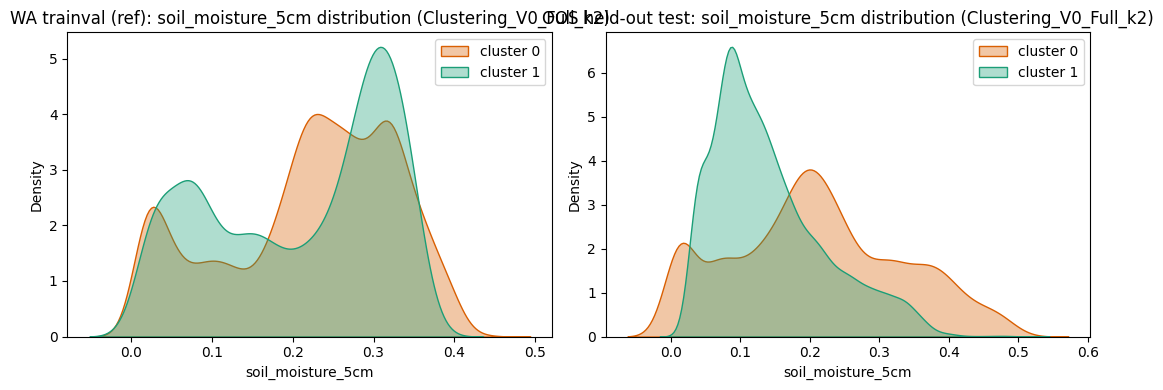


--- Share of each cluster per month ---
|   month |   ('OOS held-out test', 0) |   ('OOS held-out test', 1) |   ('WA trainval (ref)', 0) |   ('WA trainval (ref)', 1) |
|--------:|---------------------------:|---------------------------:|---------------------------:|---------------------------:|
|       1 |                      0.58  |                      0.42  |                      0.766 |                      0.234 |
|       2 |                      0.521 |                      0.479 |                      0.779 |                      0.221 |
|       3 |                      0.409 |                      0.591 |                      0.733 |                      0.267 |
|       4 |                      0.304 |                      0.696 |                      0.714 |                      0.286 |
|       5 |                      0.286 |                      0.714 |                      0.714 |                      0.286 |
|       6 |                      0.225 |                      0

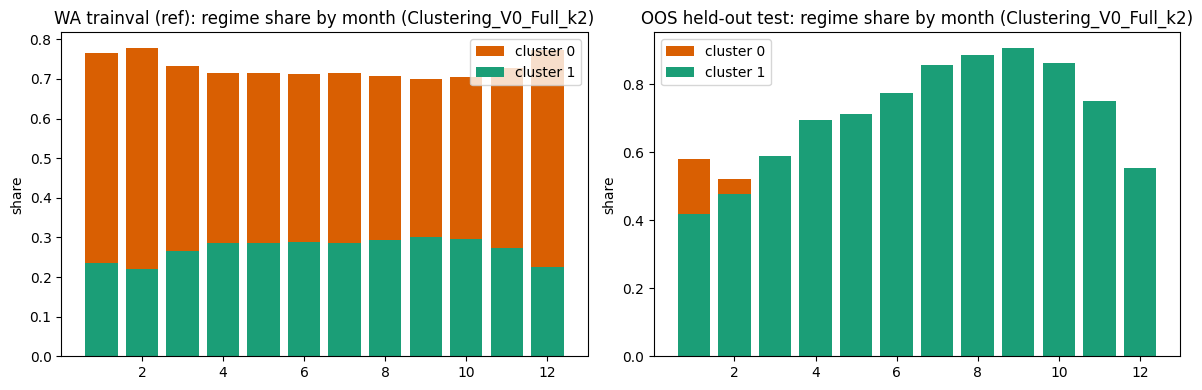


--- Share of each cluster per year ---
|   year |   ('OOS held-out', 0) |   ('OOS held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                 0.37  |                 0.63  |                0.732 |                0.268 |
|   2018 |                 0.269 |                 0.731 |                0.729 |                0.271 |
|   2019 |                 0.161 |                 0.839 |                0.736 |                0.264 |
|   2020 |                 0.157 |                 0.843 |                0.723 |                0.277 |
|   2021 |                 0.272 |                 0.728 |                0.719 |                0.281 |
|   2022 |                 0.285 |                 0.715 |                0.725 |                0.275 |
|   2023 |                 0.323 |                 0.677 |              nan     |              nan     |
|   2024 |     

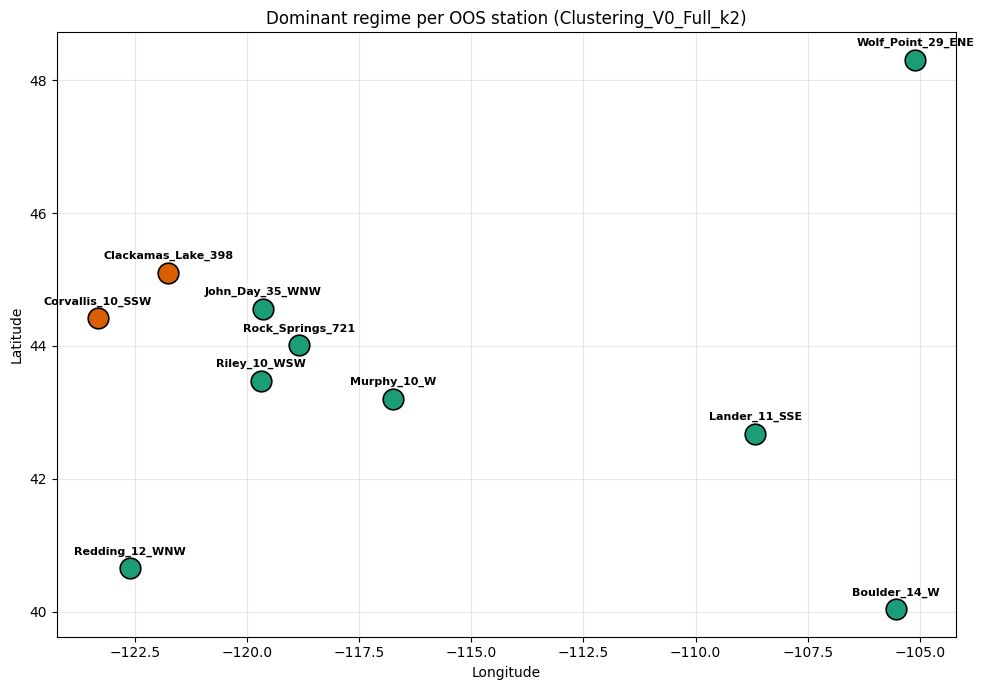


--- Weather / dynamic drivers per regime (OOS held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0.2    |            0      |            -0.205 |
| G_API             |           32.5949 |            9.116  |            -0.56  |
| G_rain_sum_7d     |           19.6    |            4.7    |            -0.407 |
| LST_modis         |          282.582  |          297.405  |             0.527 |
| SMAP_sm_pm_interp |            0.37   |            0.1545 |            -0.841 |
| G_DSLR            |            1      |            2      |             0.227 |


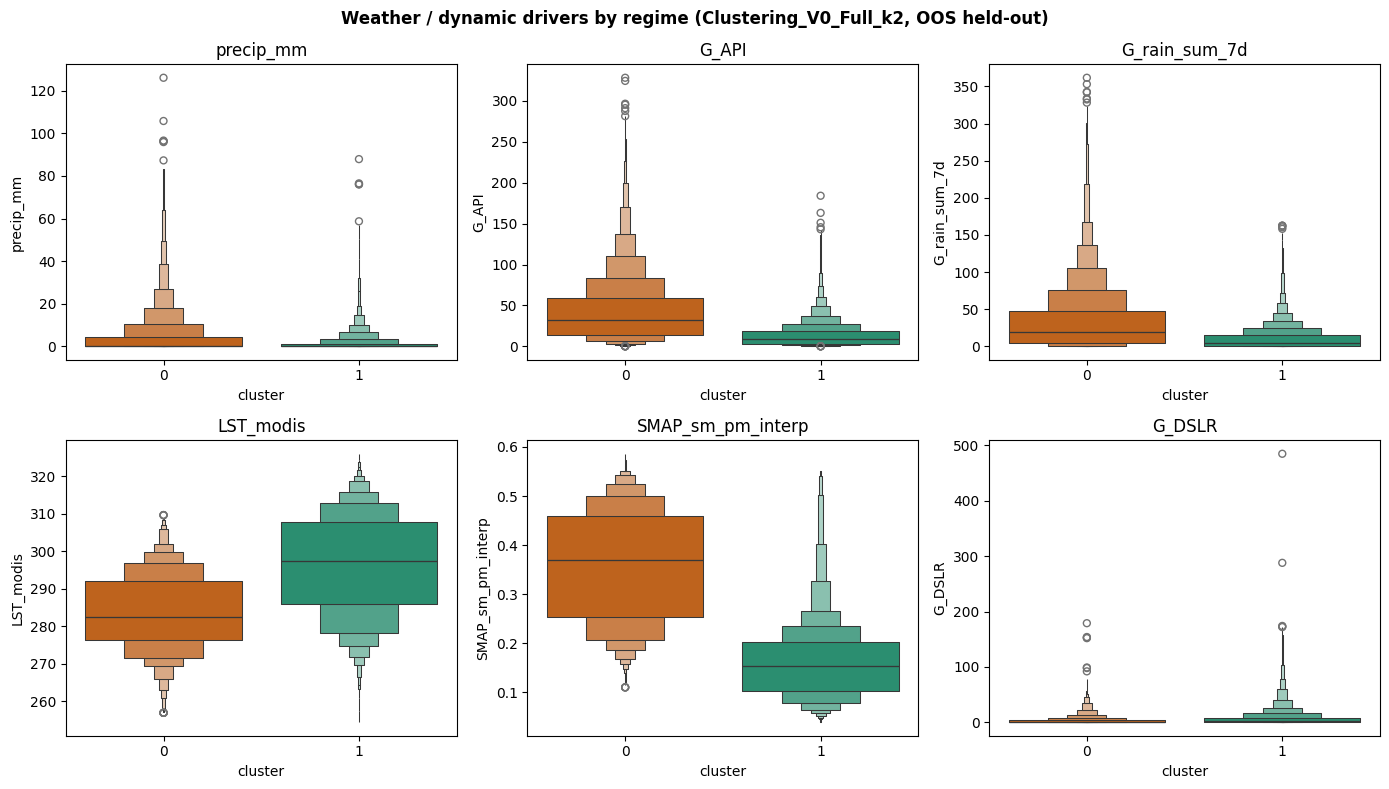


--- Static / environmental attributes per regime (OOS held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            44.419 |            43.471 |            -0.222 |
| longitude              |          -121.754 |          -118.838 |             0.642 |
| elev                   |          1073.44  |          1205.55  |             0.397 |
| slope                  |             7.446 |             9.501 |            -0.206 |
| J_soil_texture_usda_b0 |             7     |             7     |            -0.057 |
| J_lc_code              |            30     |            30     |             0.139 |


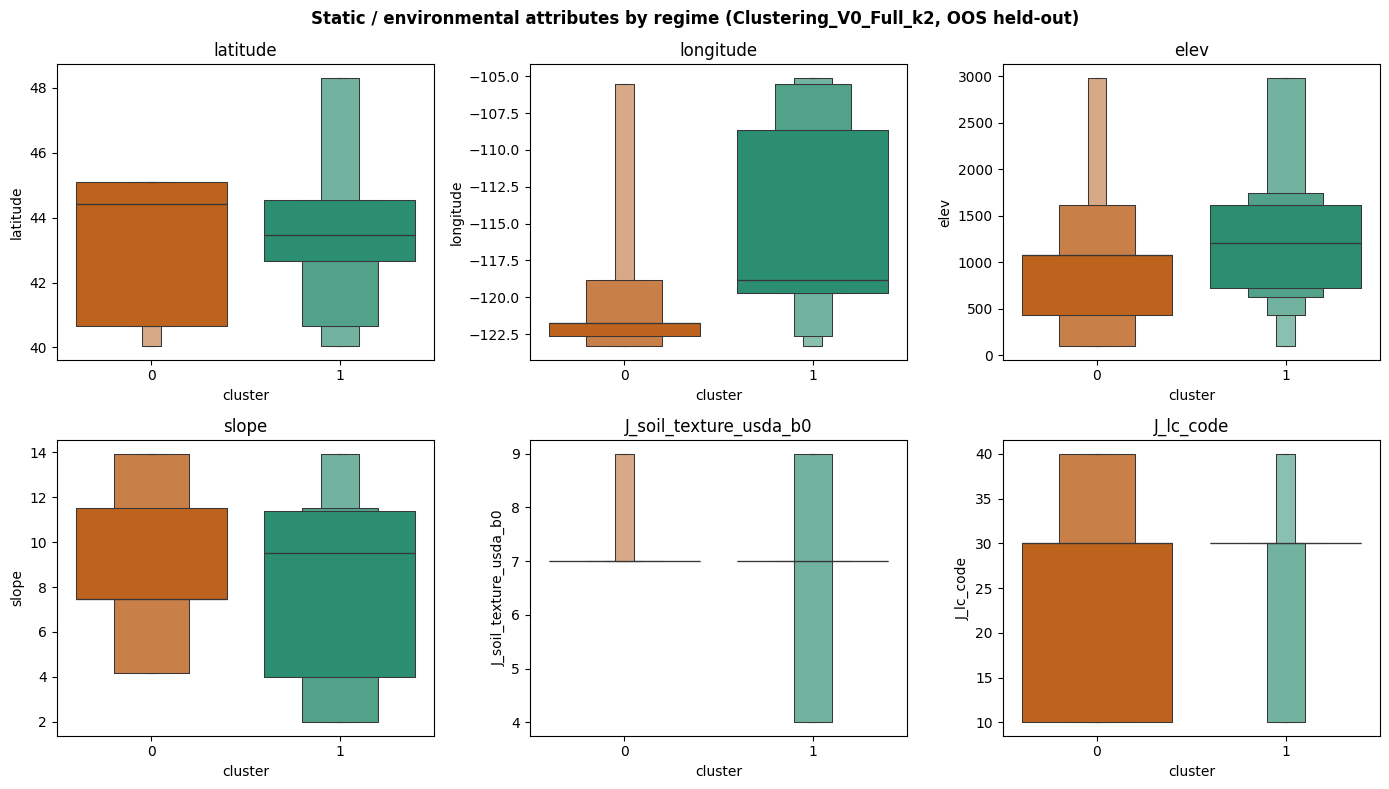


--- Top 15 V0 features separating the regimes (OOS held-out; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| SMAP_sm_pm_interp_rollmean30 |            0.3811 |            0.1552 |            -0.879 |
| V_rollmin_s2_b12_kobs30      |            0.0638 |            0.174  |             0.826 |
| SMAP_sm_pm_interp_lag30      |            0.3712 |            0.155  |            -0.82  |
| V_ema_SMAP_sm_interp_kobs30  |            0.3257 |            0.1451 |            -0.82  |
| s2_b11                       |            0.1296 |            0.254  |             0.755 |
| F_MSI                        |            0.552  |            1.1237 |             0.745 |
| V_rollmean_F_NDMI_kobs30     |            0.2742 |           -0.0222 |            -0.744 |
| J_bio_bio02                  |          116      |          152  

In [4]:
interpret_regimes("Clustering_V0_Full_k2")

### 3.2 Clustering_Dynamic_k2

We evaluate the dynamic 3-feature clustering router (`SMAP_sm_pm_interp_lag1`, `G_API`, `LST_modis`) on the out-of-state stations.


Strategy: Clustering_Dynamic_k2 (Evaluated on 10 Out-of-State Held-out Stations)

--- Regime sizes ---
cluster 0: WA trainval =  7974 (54.6%)  |  OOS held-out = 19995 (79.4%)
cluster 1: WA trainval =  6634 (45.4%)  |  OOS held-out =  5181 (20.6%)


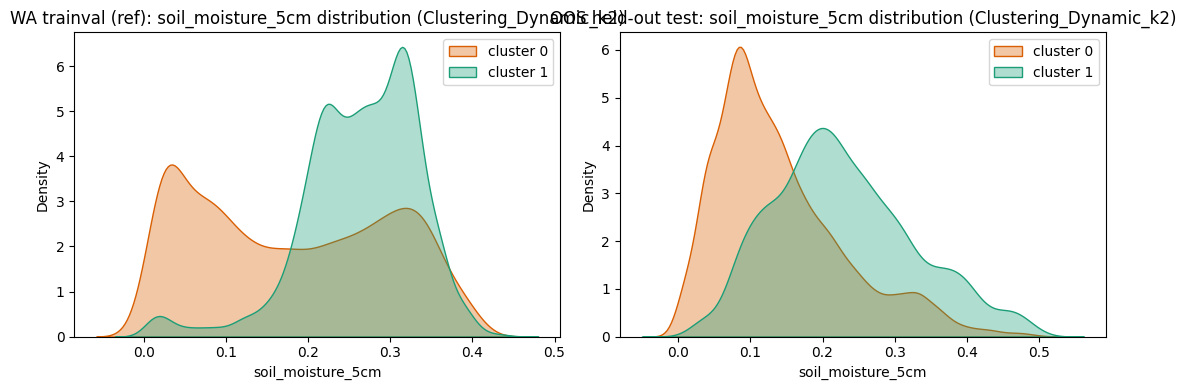


--- Share of each cluster per month ---
|   month |   ('OOS held-out test', 0) |   ('OOS held-out test', 1) |   ('WA trainval (ref)', 0) |   ('WA trainval (ref)', 1) |
|--------:|---------------------------:|---------------------------:|---------------------------:|---------------------------:|
|       1 |                      0.177 |                      0.823 |                      0.012 |                      0.988 |
|       2 |                      0.414 |                      0.586 |                      0.06  |                      0.94  |
|       3 |                      0.693 |                      0.307 |                      0.309 |                      0.691 |
|       4 |                      0.872 |                      0.128 |                      0.471 |                      0.529 |
|       5 |                      0.94  |                      0.06  |                      0.847 |                      0.153 |
|       6 |                      0.99  |                      0

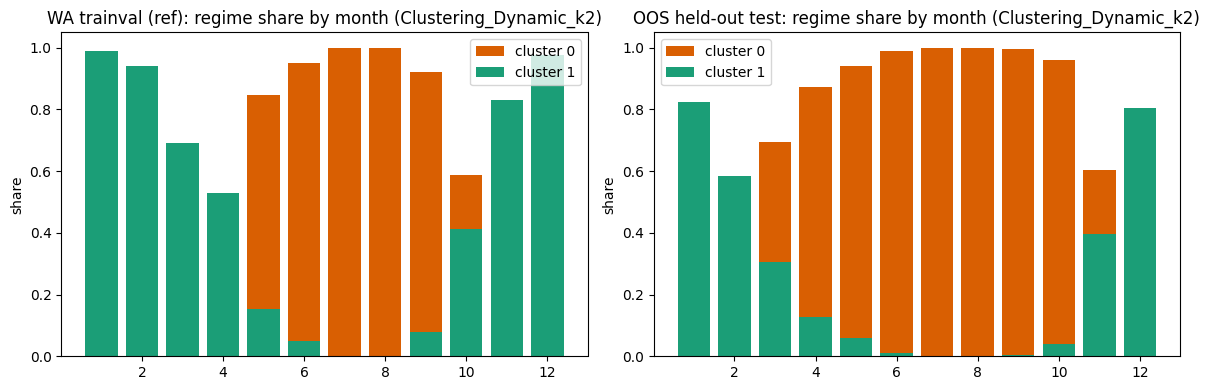


--- Share of each cluster per year ---
|   year |   ('OOS held-out', 0) |   ('OOS held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                 0.774 |                 0.226 |                0.531 |                0.469 |
|   2018 |                 0.836 |                 0.164 |                0.573 |                0.427 |
|   2019 |                 0.808 |                 0.192 |                0.567 |                0.433 |
|   2020 |                 0.852 |                 0.148 |                0.556 |                0.444 |
|   2021 |                 0.838 |                 0.162 |                0.552 |                0.448 |
|   2022 |                 0.791 |                 0.209 |                0.493 |                0.507 |
|   2023 |                 0.752 |                 0.248 |              nan     |              nan     |
|   2024 |     

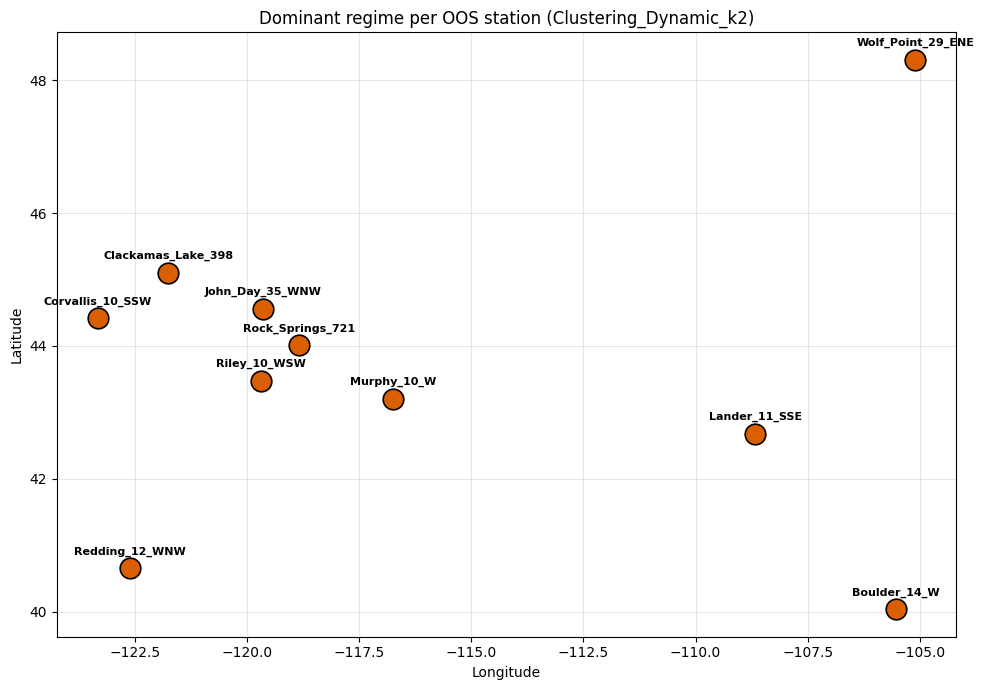


--- Weather / dynamic drivers per regime (OOS held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |            1.2    |             0.375 |
| G_API             |            8.9664 |           35.5506 |             0.694 |
| G_rain_sum_7d     |            4.2    |           25.7    |             0.603 |
| LST_modis         |          297.405  |          274.772  |            -0.953 |
| SMAP_sm_pm_interp |            0.1671 |            0.3329 |             0.631 |
| G_DSLR            |            3      |            0      |            -0.436 |


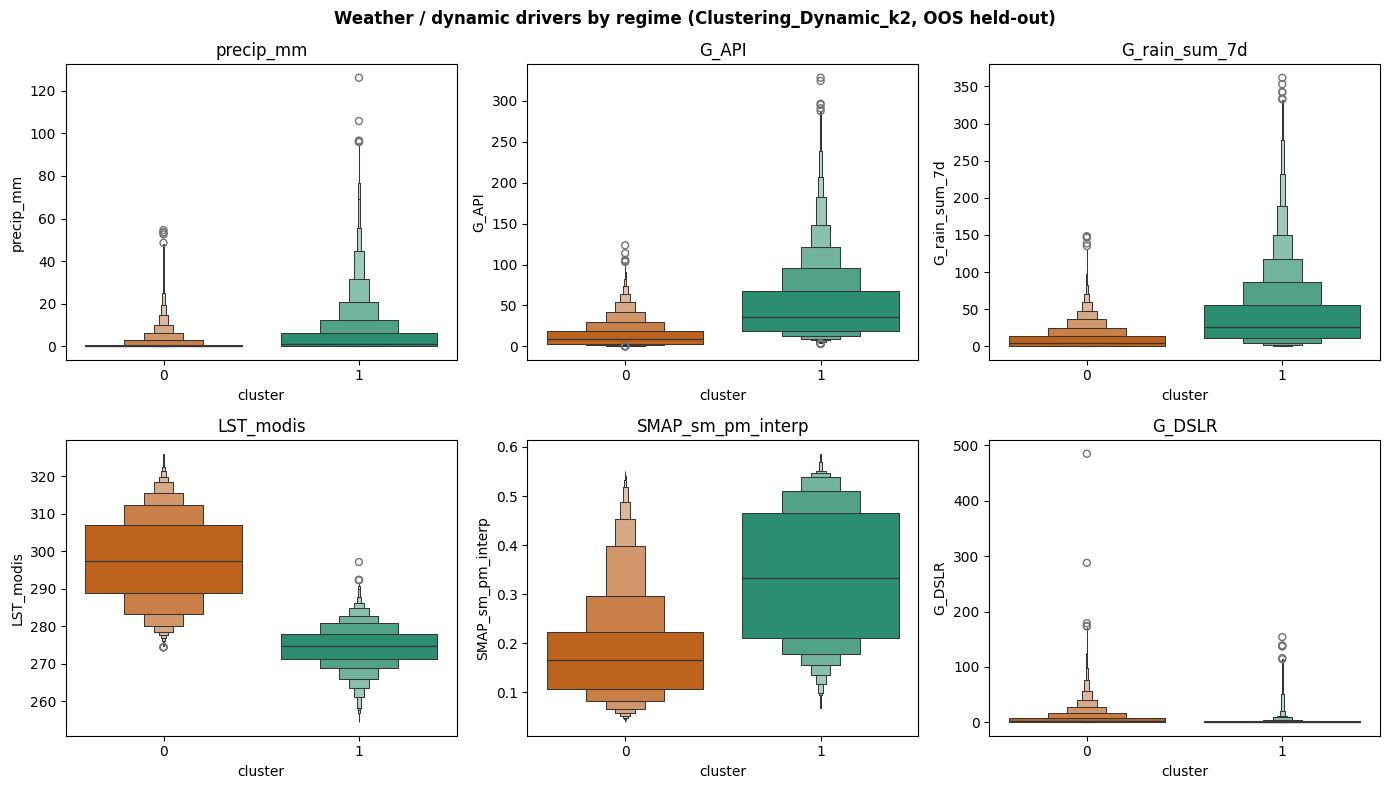


--- Static / environmental attributes per regime (OOS held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            43.471 |            44.009 |             0.156 |
| longitude              |          -119.646 |          -119.692 |            -0.236 |
| elev                   |          1205.55  |          1073.44  |            -0.06  |
| slope                  |             9.501 |             9.501 |             0.15  |
| J_soil_texture_usda_b0 |             7     |             7     |             0.062 |
| J_lc_code              |            30     |            30     |            -0.113 |


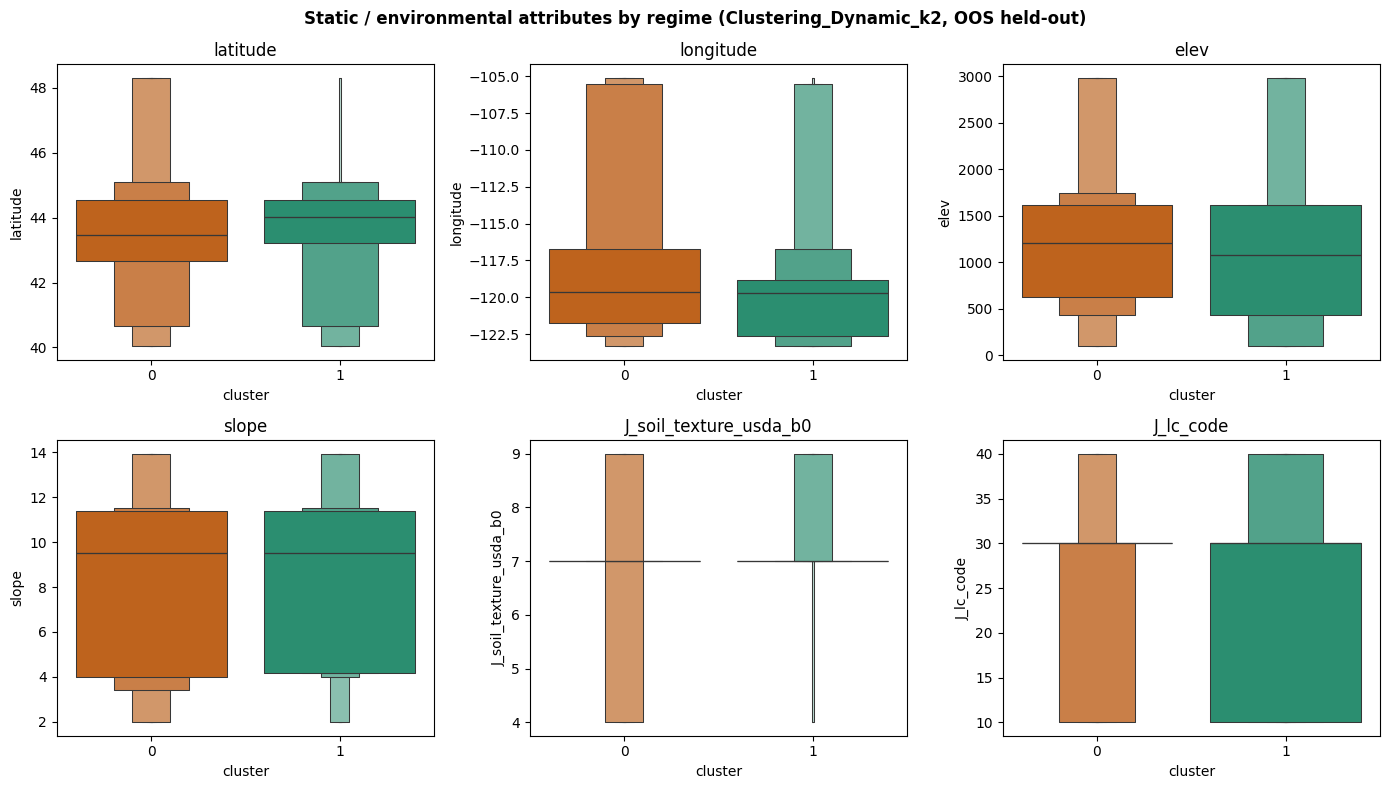


--- Top 15 V0 features separating the regimes (OOS held-out; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| V_ema_LST_modis_kobs30       |          297.009  |          276.567  |            -0.904 |
| V_rollmax_G_API_kobs7        |           12.8386 |           44.374  |             0.673 |
| V_ema_G_API_kobs30           |           10.8602 |           31.1515 |             0.634 |
| V_rollmin_s2_b12_kobs30      |            0.1585 |            0.0841 |            -0.629 |
| V_rollmin_G_API_kobs14       |            4.9321 |           19.7571 |             0.629 |
| s2_b11                       |            0.2432 |            0.1384 |            -0.625 |
| V_rollmax_G_API_kobs30       |           22.4354 |           56.9183 |             0.599 |
| SMAP_sm_pm_interp_rollmean30 |            0.1706 |            0.3

In [5]:
interpret_regimes("Clustering_Dynamic_k2")

### 3.3 Seasonal_Binary_k2

We evaluate the deterministic calendar-based split (May–Oct dry vs Nov–Apr wet) on the out-of-state stations.


Strategy: Seasonal_Binary_k2 (Evaluated on 10 Out-of-State Held-out Stations)

--- Regime sizes ---
cluster 0: WA trainval =  7559 (51.7%)  |  OOS held-out = 14579 (57.9%)
cluster 1: WA trainval =  7049 (48.3%)  |  OOS held-out = 10597 (42.1%)


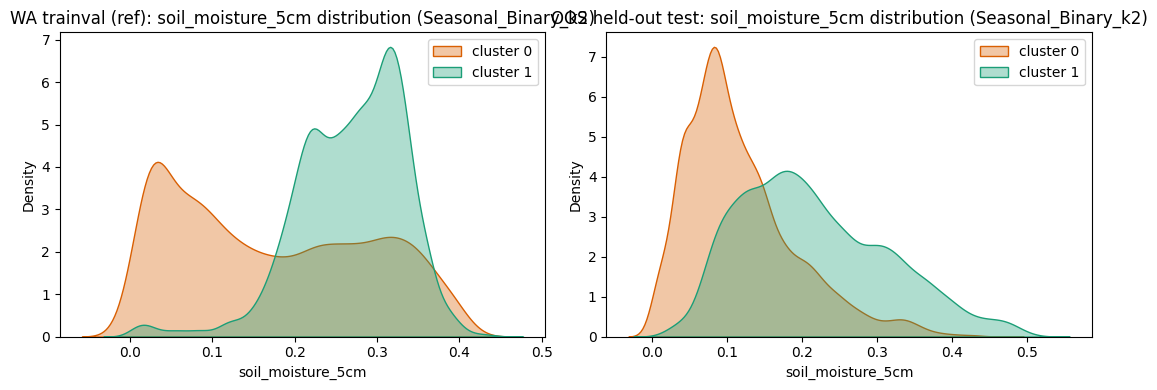


--- Share of each cluster per month ---
|   month |   ('OOS held-out test', 0) |   ('OOS held-out test', 1) |   ('WA trainval (ref)', 0) |   ('WA trainval (ref)', 1) |
|--------:|---------------------------:|---------------------------:|---------------------------:|---------------------------:|
|       1 |                          0 |                          1 |                          0 |                          1 |
|       2 |                          0 |                          1 |                          0 |                          1 |
|       3 |                          0 |                          1 |                          0 |                          1 |
|       4 |                          0 |                          1 |                          0 |                          1 |
|       5 |                          1 |                          0 |                          1 |                          0 |
|       6 |                          1 |                       

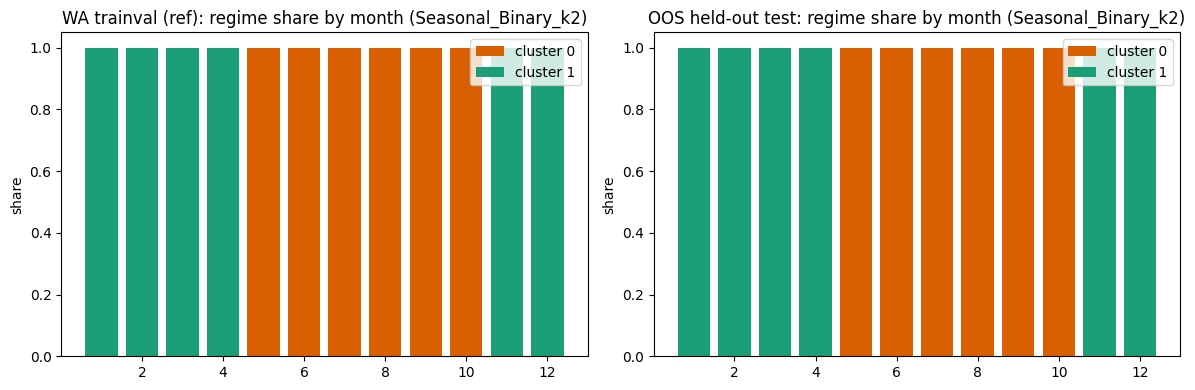


--- Share of each cluster per year ---
|   year |   ('OOS held-out', 0) |   ('OOS held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                 0.583 |                 0.417 |                0.521 |                0.479 |
|   2018 |                 0.577 |                 0.423 |                0.518 |                0.482 |
|   2019 |                 0.595 |                 0.405 |                0.531 |                0.469 |
|   2020 |                 0.584 |                 0.416 |                0.509 |                0.491 |
|   2021 |                 0.613 |                 0.387 |                0.514 |                0.486 |
|   2022 |                 0.578 |                 0.422 |                0.512 |                0.488 |
|   2023 |                 0.593 |                 0.407 |              nan     |              nan     |
|   2024 |     

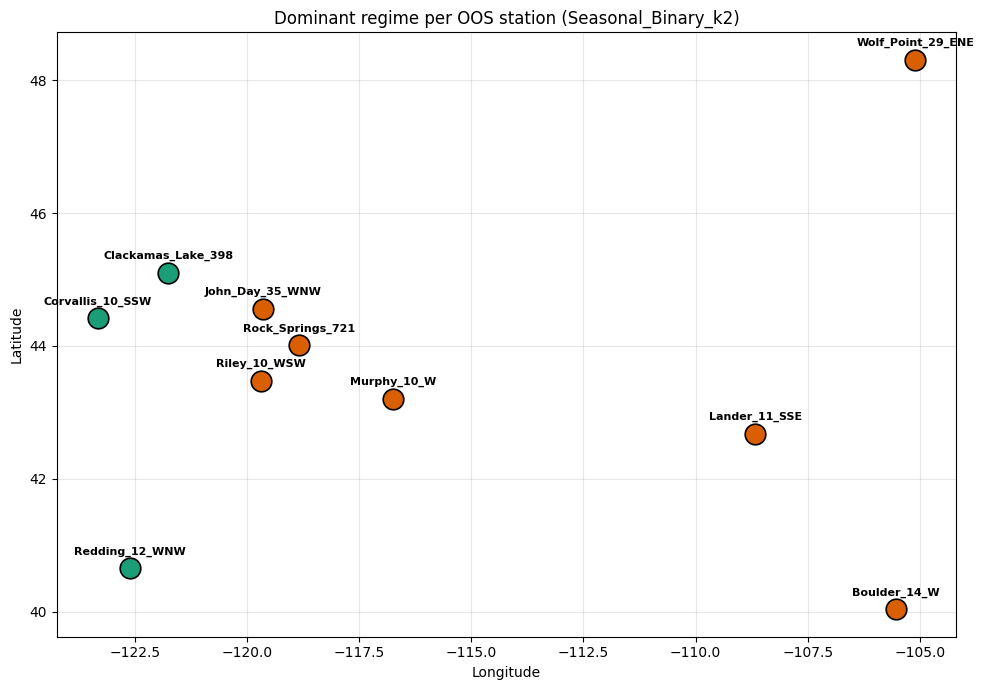


--- Weather / dynamic drivers per regime (OOS held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |            0.3    |             0.251 |
| G_API             |            7.0821 |           19.8571 |             0.499 |
| G_rain_sum_7d     |            3.2    |           13.4    |             0.389 |
| LST_modis         |          302.286  |          280.007  |            -0.864 |
| SMAP_sm_pm_interp |            0.1435 |            0.2383 |             0.609 |
| G_DSLR            |            3      |            1      |            -0.336 |


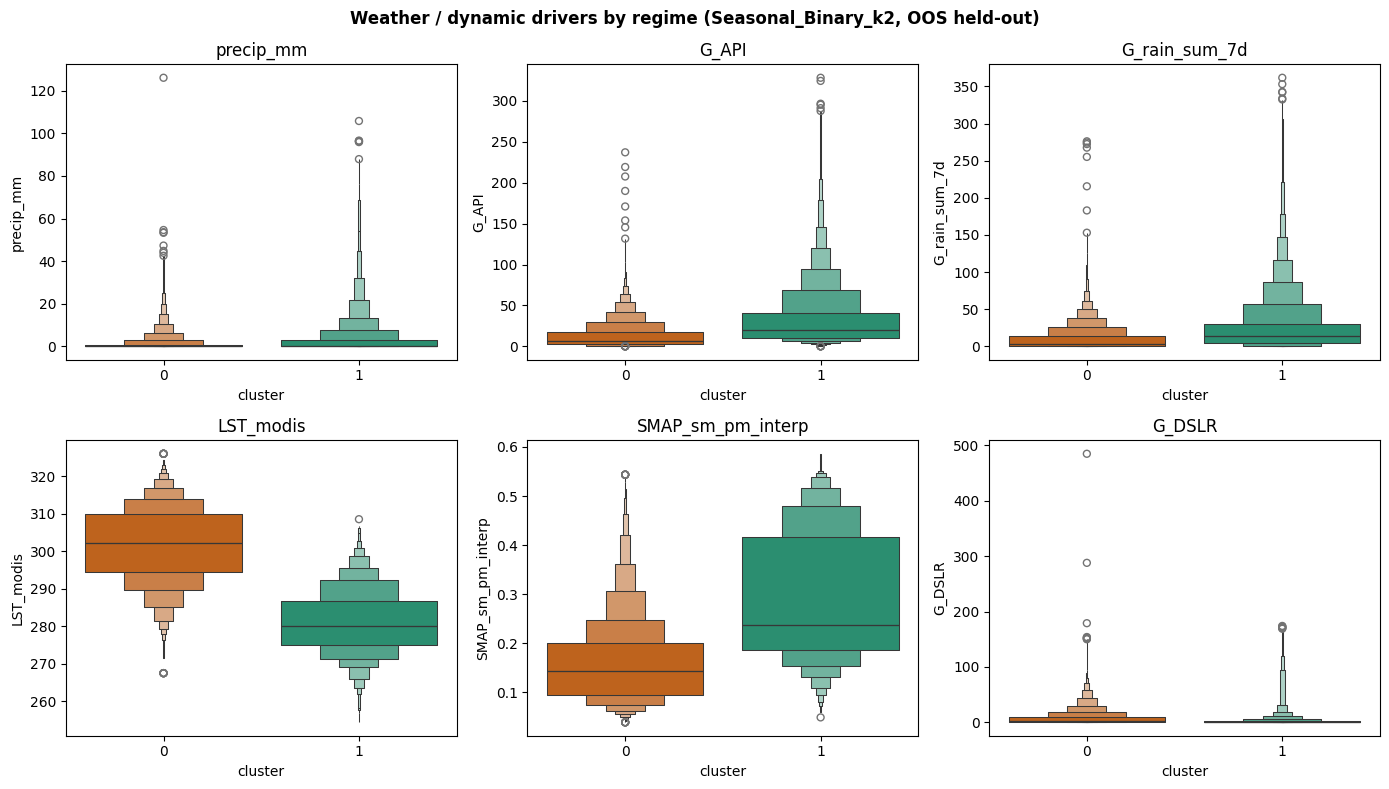


--- Static / environmental attributes per regime (OOS held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            43.471 |            44.009 |             0.084 |
| longitude              |          -118.838 |          -119.646 |            -0.209 |
| elev                   |          1205.55  |          1073.44  |            -0.141 |
| slope                  |             9.501 |             9.501 |             0.042 |
| J_soil_texture_usda_b0 |             7     |             7     |            -0.026 |
| J_lc_code              |            30     |            30     |             0.066 |


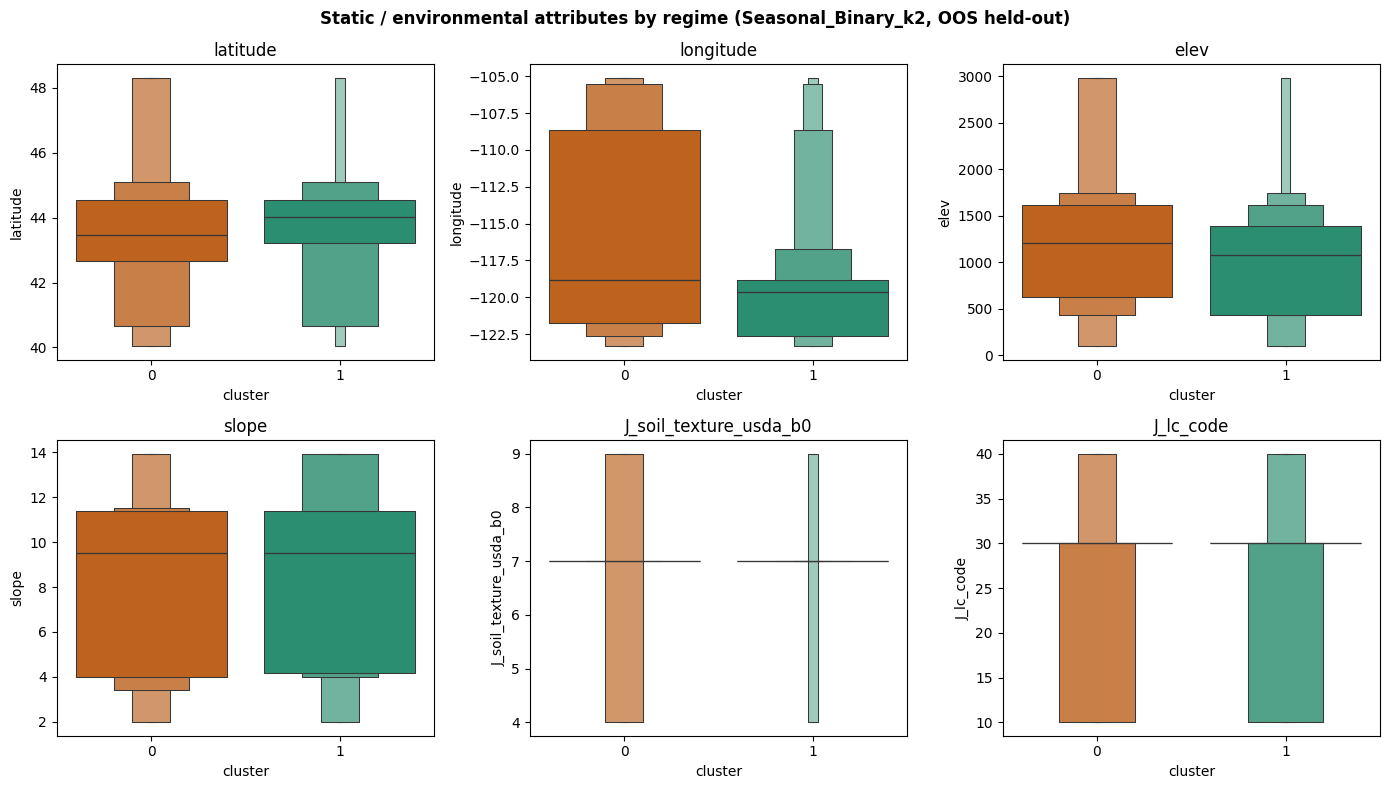


--- Top 15 V0 features separating the regimes (OOS held-out; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| V_ema_LST_modis_kobs30       |          301.772  |          280.706  |            -0.915 |
| SMAP_sm_pm_interp_rollmean30 |            0.1493 |            0.2316 |             0.573 |
| V_rollmin_G_API_kobs14       |            3.6916 |           11.6987 |             0.513 |
| V_ema_G_API_kobs30           |            9.1213 |           19.1057 |             0.488 |
| V_rollmax_G_API_kobs7        |           10.4619 |           25.331  |             0.486 |
| V_ema_SMAP_sm_interp_kobs30  |            0.1457 |            0.1962 |             0.469 |
| SMAP_sm_pm_interp_lag30      |            0.1526 |            0.2201 |             0.458 |
| V_rollmax_G_API_kobs30       |           20.1961 |           34.8

In [6]:
interpret_regimes("Seasonal_Binary_k2")

### 3.4 Univariate_G_API_k2

We evaluate the antecedent precipitation index threshold router (`G_API` median threshold) on the out-of-state stations.


Strategy: Univariate_G_API_k2 (Evaluated on 10 Out-of-State Held-out Stations)

--- Regime sizes ---
cluster 0: WA trainval =  7304 (50.0%)  |  OOS held-out = 20066 (79.7%)
cluster 1: WA trainval =  7304 (50.0%)  |  OOS held-out =  5110 (20.3%)


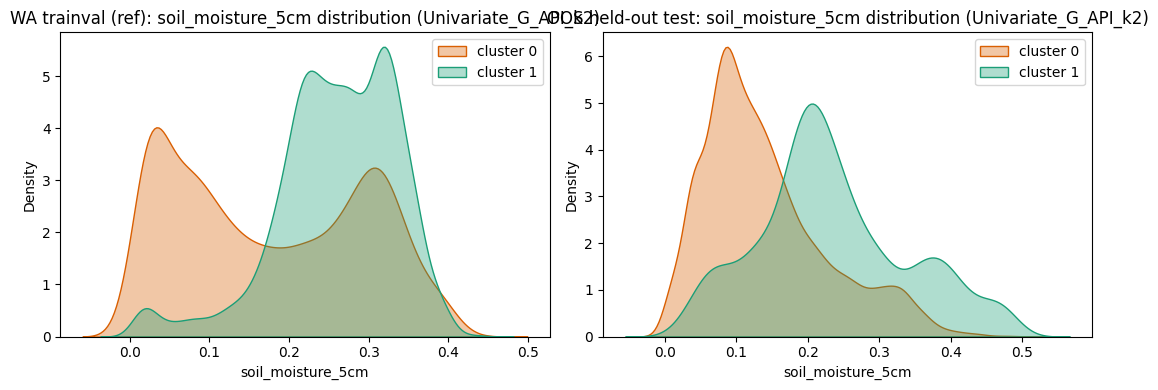


--- Share of each cluster per month ---
|   month |   ('OOS held-out test', 0) |   ('OOS held-out test', 1) |   ('WA trainval (ref)', 0) |   ('WA trainval (ref)', 1) |
|--------:|---------------------------:|---------------------------:|---------------------------:|---------------------------:|
|       1 |                      0.509 |                      0.491 |                      0.163 |                      0.837 |
|       2 |                      0.646 |                      0.354 |                      0.184 |                      0.816 |
|       3 |                      0.685 |                      0.315 |                      0.327 |                      0.673 |
|       4 |                      0.759 |                      0.241 |                      0.378 |                      0.622 |
|       5 |                      0.789 |                      0.211 |                      0.564 |                      0.436 |
|       6 |                      0.867 |                      0

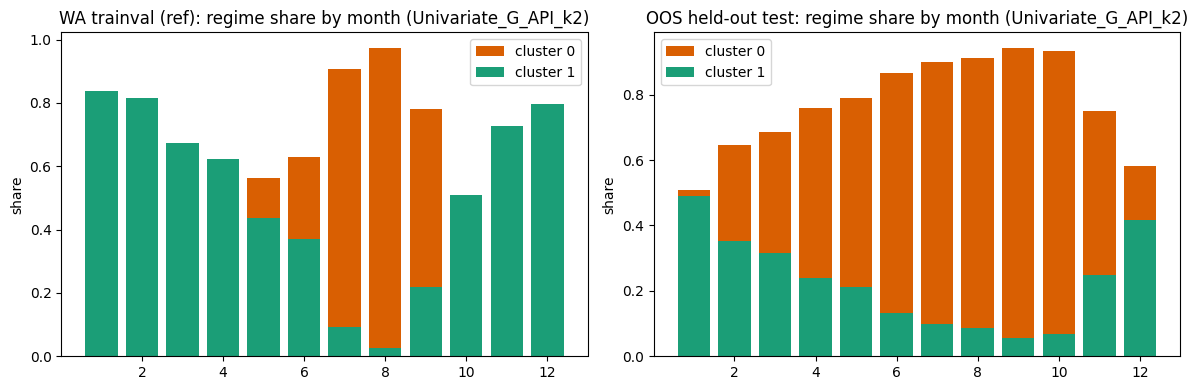


--- Share of each cluster per year ---
|   year |   ('OOS held-out', 0) |   ('OOS held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                 0.759 |                 0.241 |                0.465 |                0.535 |
|   2018 |                 0.823 |                 0.177 |                0.527 |                0.473 |
|   2019 |                 0.788 |                 0.212 |                0.546 |                0.454 |
|   2020 |                 0.87  |                 0.13  |                0.472 |                0.528 |
|   2021 |                 0.829 |                 0.171 |                0.527 |                0.473 |
|   2022 |                 0.804 |                 0.196 |                0.461 |                0.539 |
|   2023 |                 0.77  |                 0.23  |              nan     |              nan     |
|   2024 |     

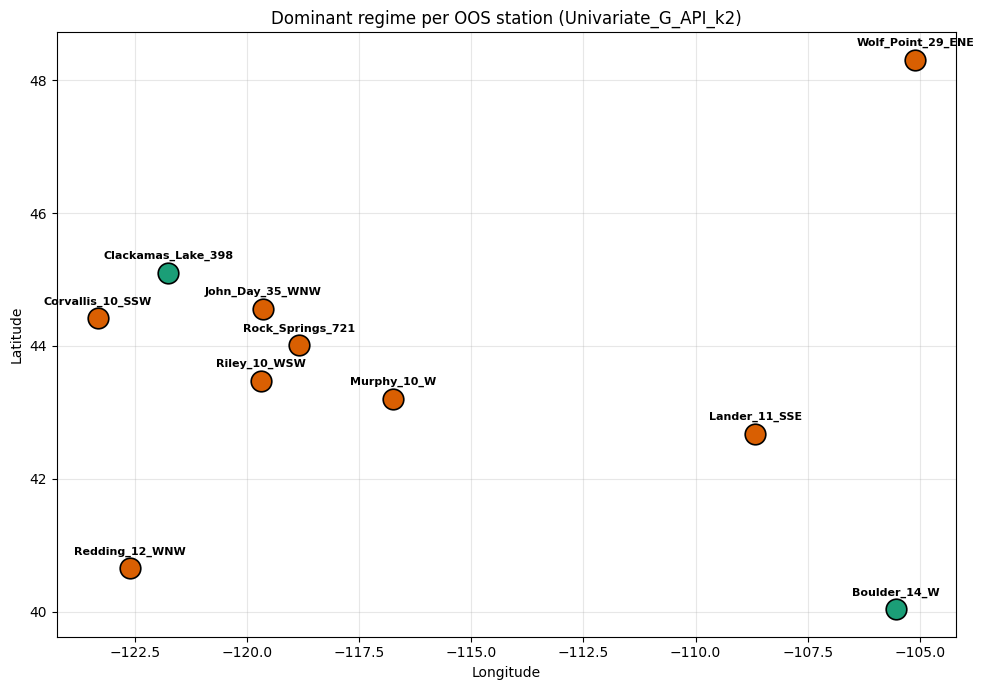


--- Weather / dynamic drivers per regime (OOS held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |            2.5    |             0.503 |
| G_API             |            8.6508 |           51.9533 |             1     |
| G_rain_sum_7d     |            3.8    |           42.8    |             0.888 |
| LST_modis         |          296.71   |          281.952  |            -0.52  |
| SMAP_sm_pm_interp |            0.1622 |            0.4003 |             0.784 |
| G_DSLR            |            3      |            0      |            -0.527 |


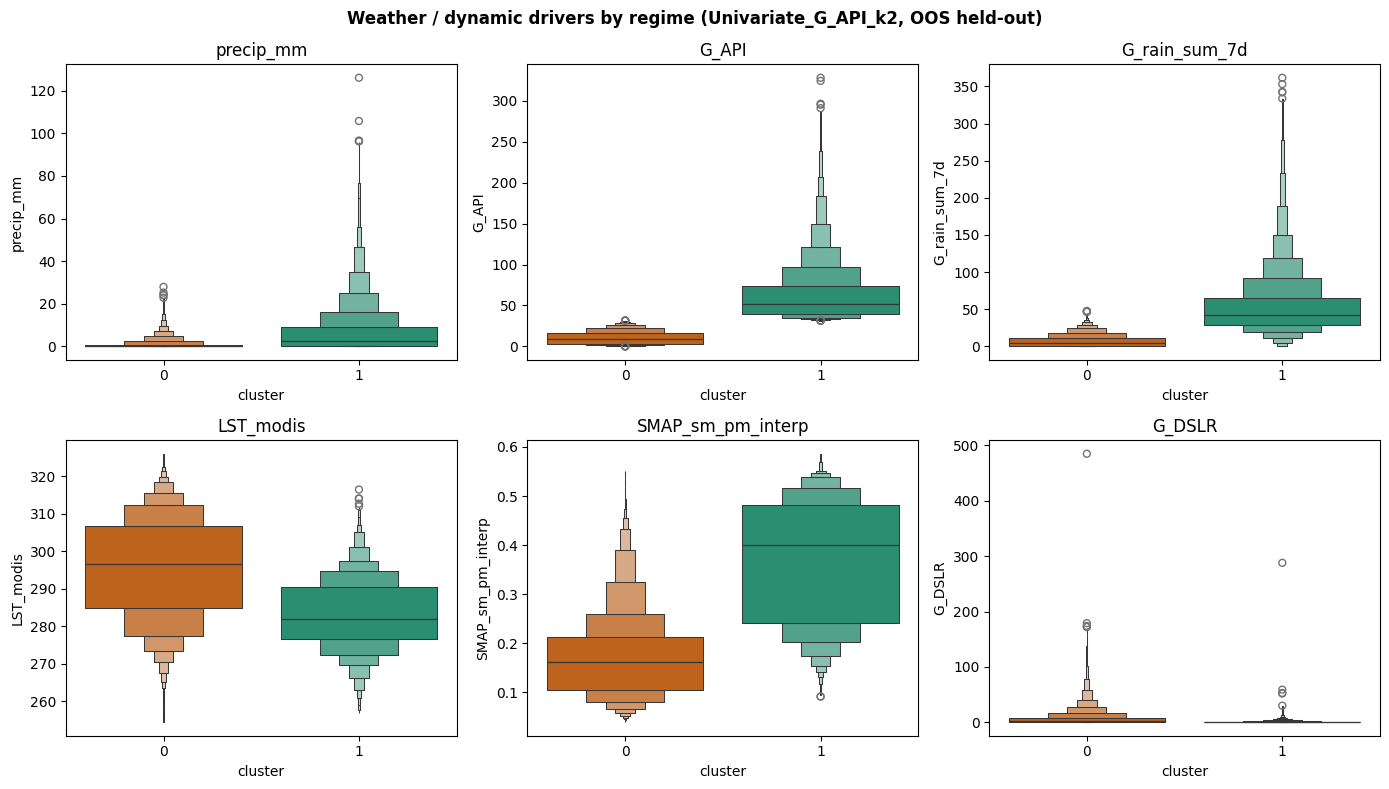


--- Static / environmental attributes per regime (OOS held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            44.009 |            44.009 |            -0.076 |
| longitude              |          -118.838 |          -121.754 |            -0.325 |
| elev                   |          1205.55  |          1073.44  |            -0.197 |
| slope                  |             9.501 |             9.501 |             0.282 |
| J_soil_texture_usda_b0 |             7     |             7     |             0.188 |
| J_lc_code              |            30     |            30     |            -0.198 |


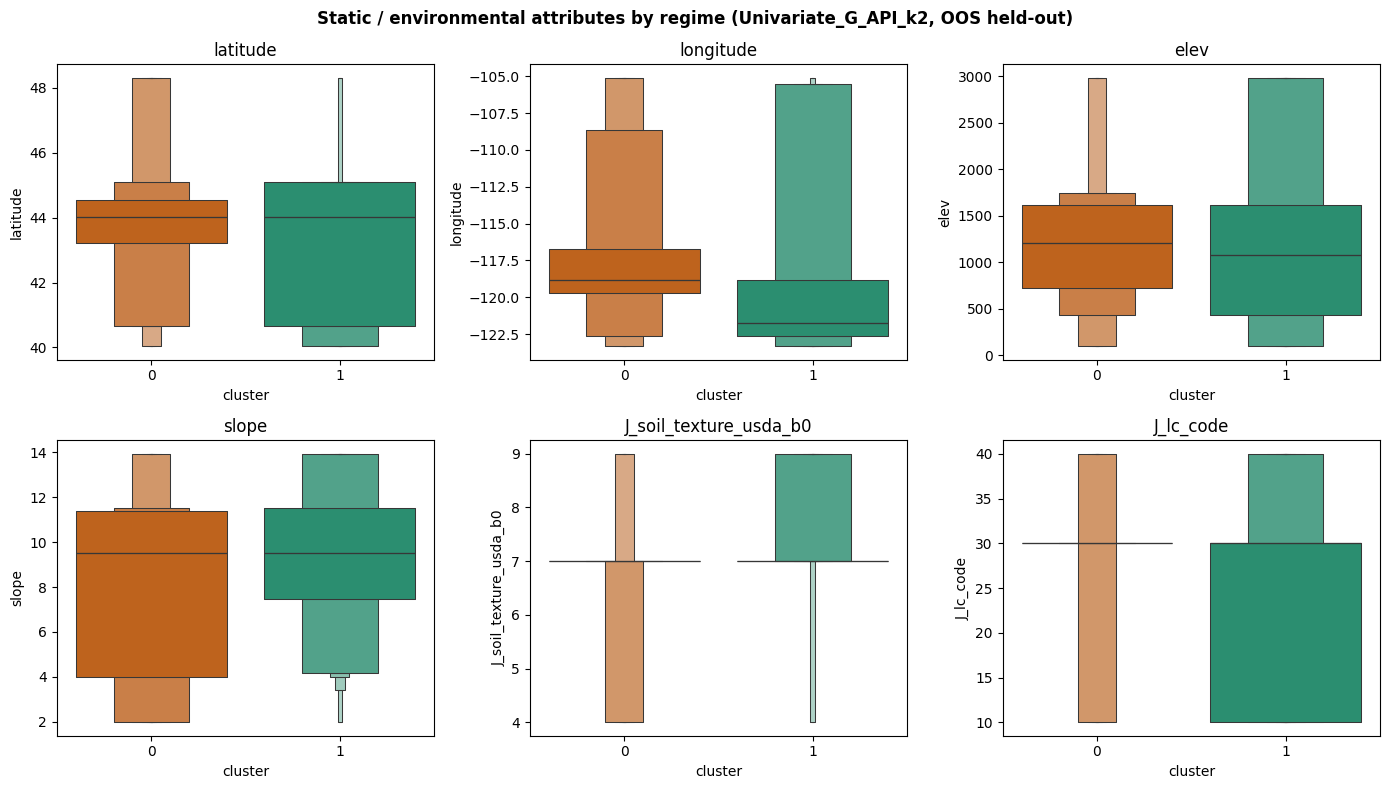


--- Top 15 V0 features separating the regimes (OOS held-out; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| V_rollmax_G_API_kobs7        |           12.3365 |           65.1333 |             0.984 |
| V_ema_G_API_kobs30           |           10.4995 |           49.2077 |             0.912 |
| V_rollmax_G_API_kobs30       |           21.1186 |           85.3408 |             0.909 |
| V_rollrng_G_API_kobs30       |           16.4041 |           58.5316 |             0.873 |
| V_rollmin_G_API_kobs14       |            4.8381 |           32.5555 |             0.845 |
| SMAP_sm_pm_interp_rollmean30 |            0.1633 |            0.3775 |             0.736 |
| V_ema_SMAP_sm_interp_kobs30  |            0.1511 |            0.3322 |             0.709 |
| SMAP_sm_pm_interp_lag30      |            0.1649 |            0.3

In [7]:
interpret_regimes("Univariate_G_API_k2")

### 3.5 Trained_Gating_k2

We evaluate the supervised logistic classifier trained on `soil_moisture_5cm < 0.16` on the out-of-state stations.


Strategy: Trained_Gating_k2 (Evaluated on 10 Out-of-State Held-out Stations)

--- Regime sizes ---
cluster 0: WA trainval =  4181 (28.6%)  |  OOS held-out = 11834 (47.0%)
cluster 1: WA trainval = 10427 (71.4%)  |  OOS held-out = 13342 (53.0%)


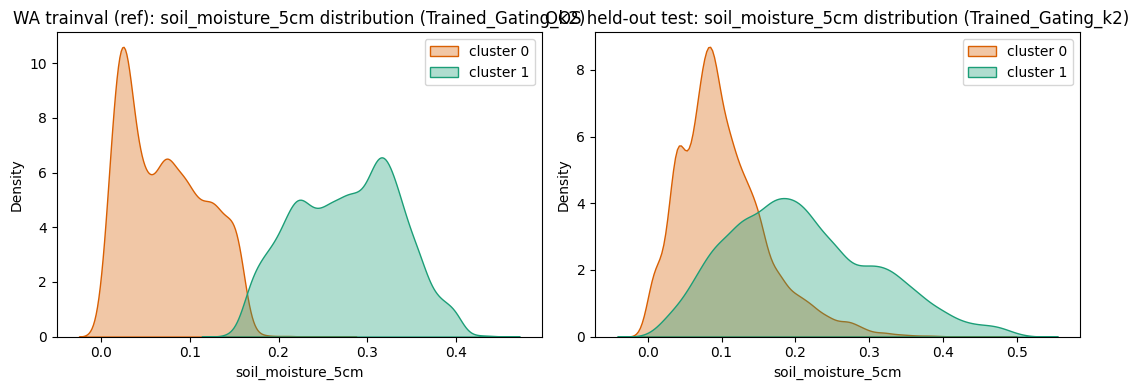


--- Share of each cluster per month ---
|   month |   ('OOS held-out test', 0) |   ('OOS held-out test', 1) |   ('WA trainval (ref)', 0) |   ('WA trainval (ref)', 1) |
|--------:|---------------------------:|---------------------------:|---------------------------:|---------------------------:|
|       1 |                      0.009 |                      0.991 |                      0.01  |                      0.99  |
|       2 |                      0.021 |                      0.979 |                      0     |                      1     |
|       3 |                      0.024 |                      0.976 |                      0     |                      1     |
|       4 |                      0.12  |                      0.88  |                      0.001 |                      0.999 |
|       5 |                      0.349 |                      0.651 |                      0.089 |                      0.911 |
|       6 |                      0.651 |                      0

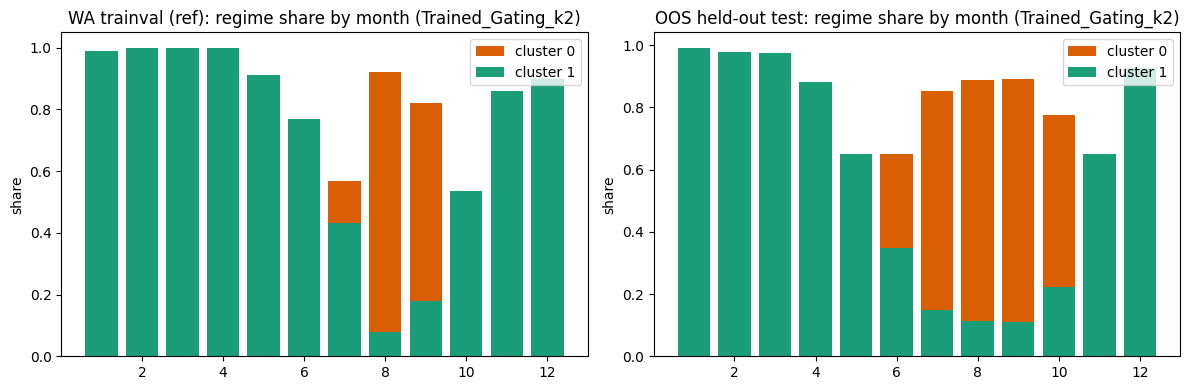


--- Share of each cluster per year ---
|   year |   ('OOS held-out', 0) |   ('OOS held-out', 1) |   ('WA trainval', 0) |   ('WA trainval', 1) |
|-------:|----------------------:|----------------------:|---------------------:|---------------------:|
|   2017 |                 0.464 |                 0.536 |                0.316 |                0.684 |
|   2018 |                 0.517 |                 0.483 |                0.351 |                0.649 |
|   2019 |                 0.466 |                 0.534 |                0.216 |                0.784 |
|   2020 |                 0.507 |                 0.493 |                0.243 |                0.757 |
|   2021 |                 0.51  |                 0.49  |                0.29  |                0.71  |
|   2022 |                 0.43  |                 0.57  |                0.302 |                0.698 |
|   2023 |                 0.428 |                 0.572 |              nan     |              nan     |
|   2024 |     

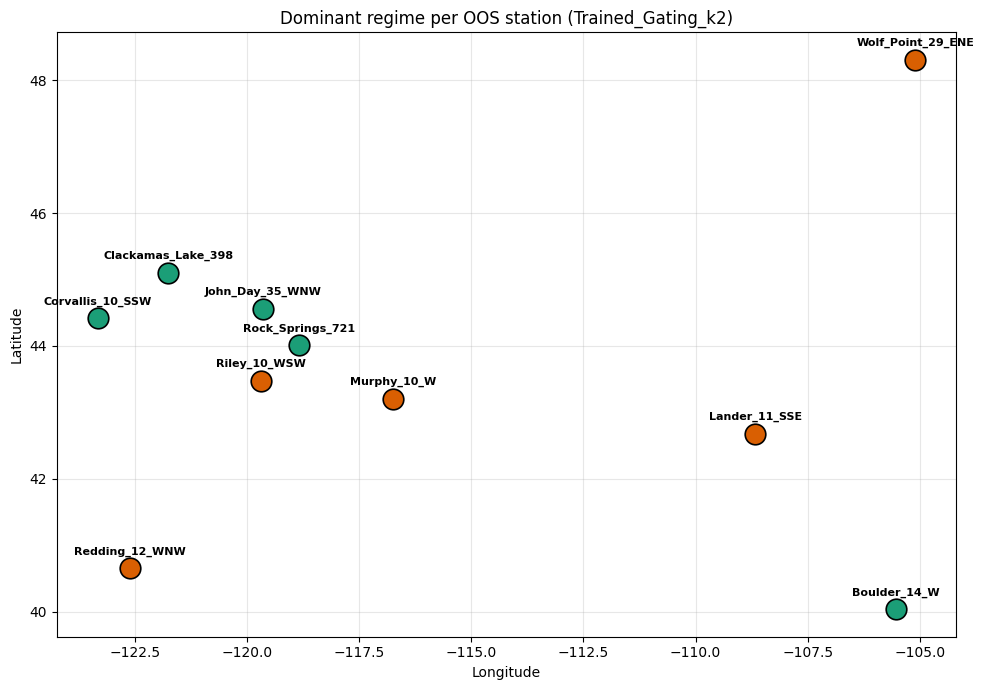


--- Weather / dynamic drivers per regime (OOS held-out; r > 0 => higher in cluster 1) ---
| feature           |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:------------------|------------------:|------------------:|------------------:|
| precip_mm         |            0      |            0.3    |             0.35  |
| G_API             |            4.3816 |           23.6737 |             0.798 |
| G_rain_sum_7d     |            1.6    |           16.1    |             0.615 |
| LST_modis         |          304.118  |          283.2    |            -0.756 |
| SMAP_sm_pm_interp |            0.1239 |            0.2317 |             0.717 |
| G_DSLR            |            5      |            1      |            -0.474 |


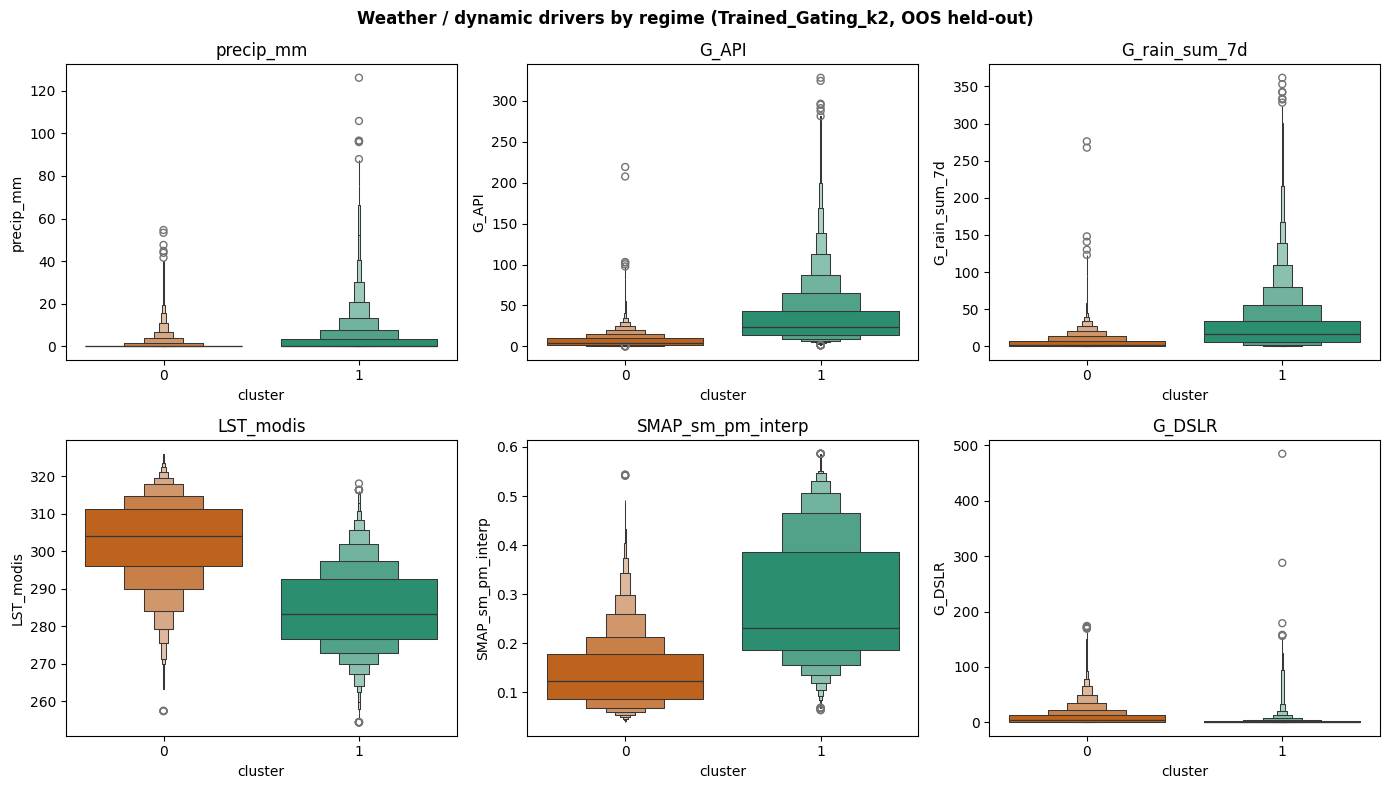


--- Static / environmental attributes per regime (OOS held-out) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            43.471 |            44.009 |            -0.063 |
| longitude              |          -119.646 |          -119.646 |            -0.022 |
| elev                   |          1205.55  |          1073.44  |             0.068 |
| slope                  |             7.446 |             9.501 |             0.183 |
| J_soil_texture_usda_b0 |             7     |             7     |             0.175 |
| J_lc_code              |            30     |            30     |            -0.14  |


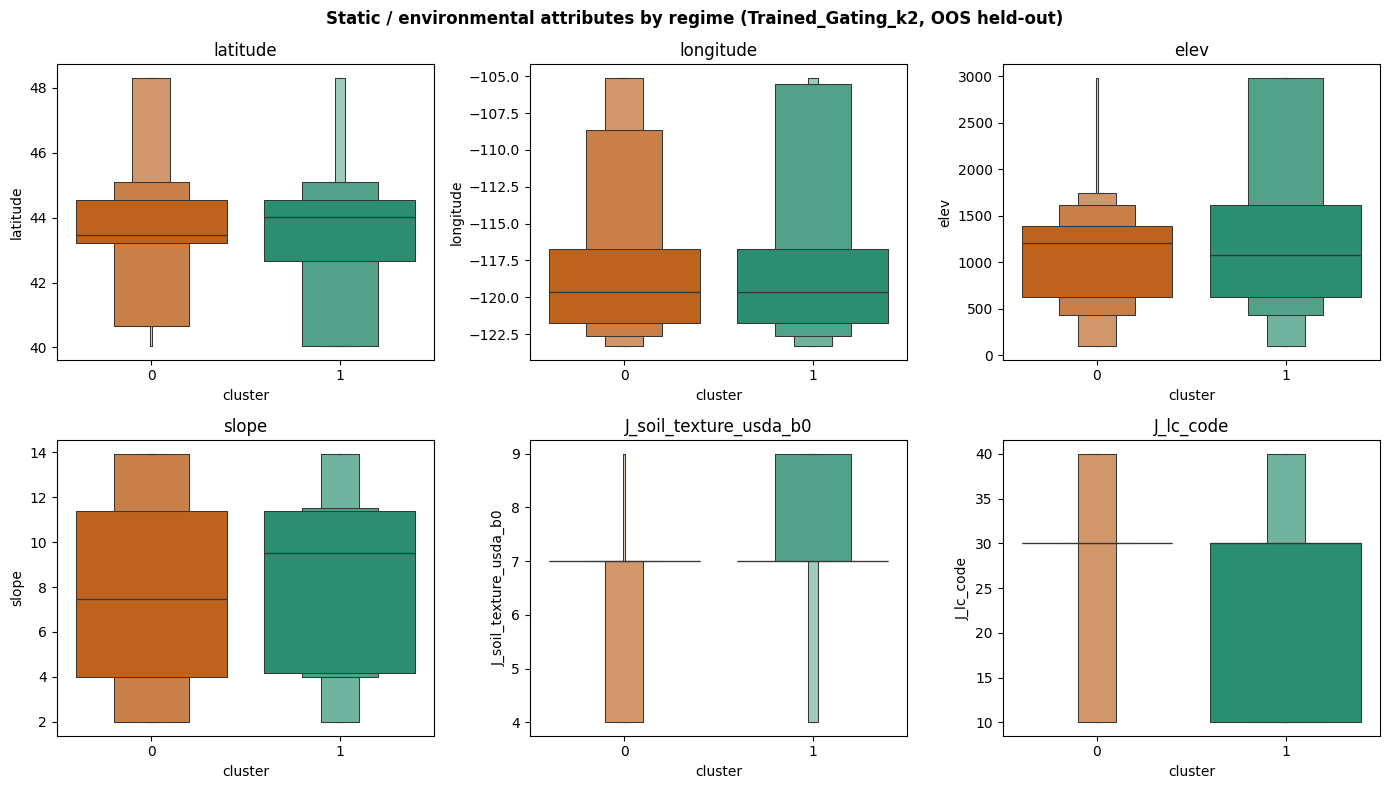


--- Top 15 V0 features separating the regimes (OOS held-out; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| V_ema_LST_modis_kobs30       |          304.396  |          282.958  |            -0.872 |
| V_rollmin_G_API_kobs14       |            2.1622 |           14.3341 |             0.856 |
| V_ema_G_API_kobs30           |            6.4135 |           23.7561 |             0.854 |
| V_rollmax_G_API_kobs7        |            6.6141 |           31.0392 |             0.804 |
| V_rollmax_G_API_kobs30       |           14.4629 |           44.008  |             0.774 |
| SMAP_sm_pm_interp_rollmean30 |            0.1244 |            0.2257 |             0.727 |
| V_rollrng_G_API_kobs30       |           12.2421 |           32.477  |             0.69  |
| V_ema_SMAP_sm_interp_kobs30  |            0.1247 |            0.1

In [8]:
interpret_regimes("Trained_Gating_k2")

### 3.6 Geographic & physical deep dive: why the Clustering_V0_Full_k2 regimes are physical across the Western US

We conduct a deep geographic and physical characterization of the winning `Clustering_V0_Full_k2` router on the held-out out-of-state stations, examining how the unsupervised 50-feature clustering generalises across Western US eco-regions.

In [9]:
"""3.6.1 Per-station physical profile: cluster assignment + climate / soil / terrain / satellite attributes."""
static_wa = pd.read_csv(SPLIT_DIR_WA / "station_static_features.csv")
static_oos = pd.read_csv(SPLIT_DIR_OOS / "station_static_features.csv")
static_all = pd.concat([static_wa, static_oos], ignore_index=True).drop_duplicates("station_id")

lbl_oos_v0 = labels[("Clustering_V0_Full_k2", "test")]

BIOCLIM_LABELS = {
    "J_bio_bio01": "BIO01_annual_mean_temp_C",
    "J_bio_bio04": "BIO04_temp_seasonality_sd",
    "J_bio_bio05": "BIO05_max_temp_warmest_month_C",
    "J_bio_bio06": "BIO06_min_temp_coldest_month_C",
    "J_bio_bio07": "BIO07_temp_annual_range_C",
    "J_bio_bio12": "BIO12_annual_precip_mm",
    "J_bio_bio13": "BIO13_precip_wettest_month_mm",
    "J_bio_bio14": "BIO14_precip_driest_month_mm",
    "J_bio_bio15": "BIO15_precip_seasonality_CV",
    "J_bio_bio16": "BIO16_precip_wettest_quarter_mm",
    "J_bio_bio17": "BIO17_precip_driest_quarter_mm",
}

clim_cols = ["SMAP_sm_pm_interp", "F_NDVI", "F_NDMI", "F_MSI", "LST_modis"]
clim_oos = oos_all.groupby("station_id")[clim_cols].mean().add_prefix("clim_")

rows = []
for sid, grp in oos_all.groupby("station_id"):
    mask = (oos_all["station_id"] == sid).to_numpy()
    cluster_shares = [(lbl_oos_v0[mask] == c).mean() for c in [0, 1]]
    dominant_cluster = int(np.argmax(cluster_shares))
    purity = float(np.max(cluster_shares))
    s = static_all[static_all["station_id"] == sid].iloc[0]
    r = {
        "station_id": sid,
        "cluster": dominant_cluster,
        "purity": round(purity, 3),
        "share_c1": round(float(cluster_shares[1]), 3),
        "longitude": round(float(s["longitude"]), 4),
        "latitude": round(float(s["latitude"]), 4),
        "elev": round(float(s["J_elev_m"]), 2),
        "slope": round(float(s["J_slope_deg"]), 2),
        "aspect": round(float(s["J_aspect_deg"]), 2),
    }
    for jcol, label in BIOCLIM_LABELS.items():
        val = float(s[jcol])
        r[label] = round(val / 10.0, 2) if label.endswith("_C") else round(val, 1)
    for col in ["J_clay_wfrac_b0", "J_clay_wfrac_b30", "J_clay_wfrac_b100", "J_sand_wfrac_b0",
                "J_sand_wfrac_b100", "J_soil_texture_usda_b0", "K_sand_clay_ratio_b0",
                "K_aspect_cos", "J_lc_code"]:
        r[col] = round(float(s[col]), 3)
    r["landcover_label"] = str(s["landcover_label"])
    for col in clim_cols:
        r[f"clim_{col}"] = round(float(clim_oos.loc[sid, f"clim_{col}"]), 4)
    rows.append(r)

df_profile = pd.DataFrame(rows).sort_values(["cluster", "longitude"], ascending=[True, False])
df_profile.to_csv(EXP_DIR / "v0full_station_physical_profile.csv", index=False)
print(df_profile.to_markdown(index=False))
print(f"\nSaved v0full_station_physical_profile.csv ({len(df_profile)} stations)")

| station_id         |   cluster |   purity |   share_c1 |   longitude |   latitude |   elev |   slope |   aspect |   BIO01_annual_mean_temp_C |   BIO04_temp_seasonality_sd |   BIO05_max_temp_warmest_month_C |   BIO06_min_temp_coldest_month_C |   BIO07_temp_annual_range_C |   BIO12_annual_precip_mm |   BIO13_precip_wettest_month_mm |   BIO14_precip_driest_month_mm |   BIO15_precip_seasonality_CV |   BIO16_precip_wettest_quarter_mm |   BIO17_precip_driest_quarter_mm |   J_clay_wfrac_b0 |   J_clay_wfrac_b30 |   J_clay_wfrac_b100 |   J_sand_wfrac_b0 |   J_sand_wfrac_b100 |   J_soil_texture_usda_b0 |   K_sand_clay_ratio_b0 |   K_aspect_cos |   J_lc_code | landcover_label   |   clim_SMAP_sm_pm_interp |   clim_F_NDVI |   clim_F_NDMI |   clim_F_MSI |   clim_LST_modis |
|:-------------------|----------:|---------:|-----------:|------------:|-----------:|-------:|--------:|---------:|---------------------------:|----------------------------:|---------------------------------:|------------------

### 3.6.2 Physiographic context — Western US station map and eco-regional distribution

We map the out-of-state held-out stations alongside the Washington reference stations across Western US topography.

Saved v0full_station_map.png


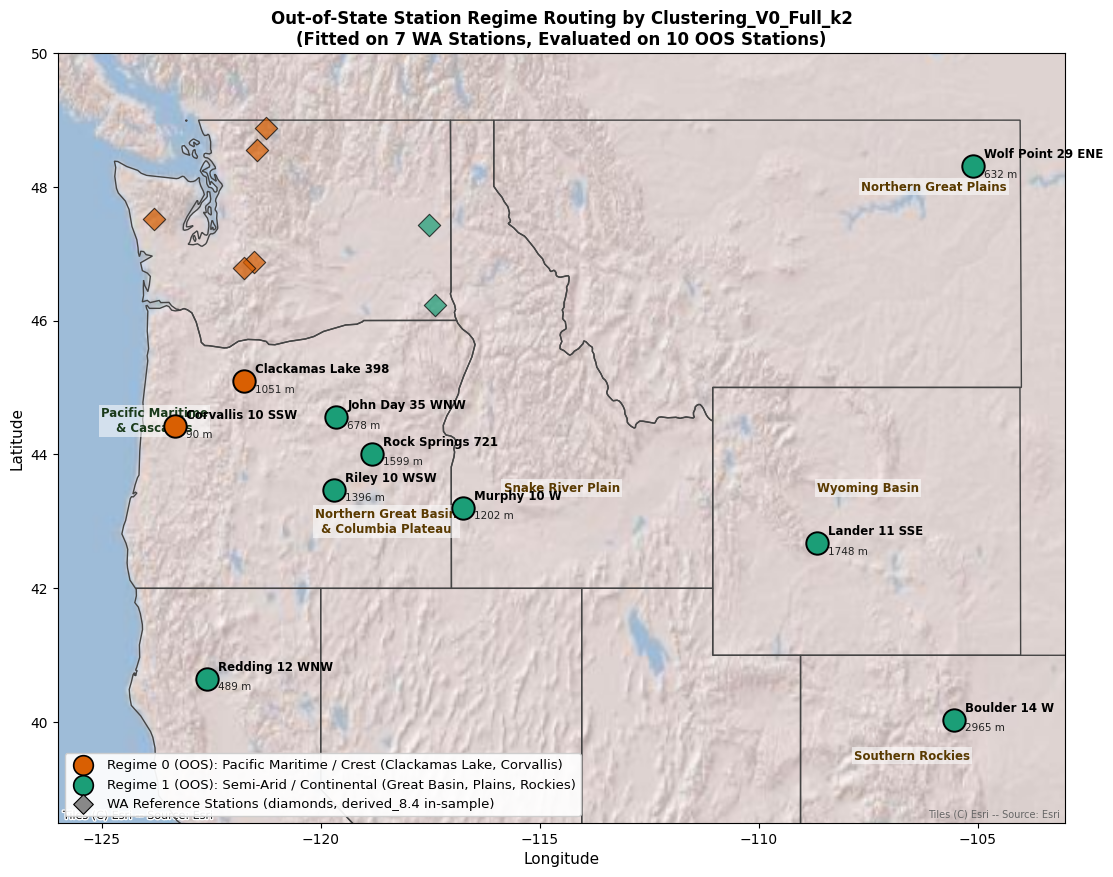

In [10]:
"""3.6.2b Western US Station location map — terrain basemap (Esri World_Shaded_Relief)."""
import json
import urllib.request
import contextily as ctx
from matplotlib.patches import Polygon as MplPolygon

boundary_path = EXP_DIR / "wa_admin1_boundary.geojson"
if not boundary_path.exists():
    NE_URL = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/"
              "geojson/ne_50m_admin_1_states_provinces.geojson")
    with urllib.request.urlopen(NE_URL, timeout=60) as resp:
        boundary_path.write_bytes(resp.read())

all_states = json.loads(boundary_path.read_text())
west_states = ["Washington", "Oregon", "California", "Idaho", "Nevada", "Utah", "Arizona", "Montana", "Wyoming", "Colorado", "New Mexico"]
state_geoms = {f["properties"]["name"]: f["geometry"] for f in all_states["features"] if f["properties"].get("name") in west_states}


def extract_rings(geom):
    if geom["type"] == "Polygon":
        return geom["coordinates"]
    return [ring for poly in geom["coordinates"] for ring in poly]


palette_map = {0: "#D95F02", 1: "#1B9E77"}
df_map = df_profile[["station_id", "longitude", "latitude", "cluster", "elev"]].copy()

# Add WA reference stations for visual geographic context
lbl_wa_v0 = labels[("Clustering_V0_Full_k2", "trainval")]
wa_rows = []
for sid, grp in trainval_wa.groupby("station_id"):
    mask = (trainval_wa["station_id"] == sid).to_numpy()
    c = int(lbl_wa_v0[mask][0])
    s = static_wa[static_wa["station_id"] == sid].iloc[0]
    wa_rows.append({
        "station_id": sid,
        "longitude": float(s["longitude"]),
        "latitude": float(s["latitude"]),
        "cluster": c,
        "elev": float(s["J_elev_m"]),
    })
df_wa_map = pd.DataFrame(wa_rows)

fig, ax = plt.subplots(figsize=(13, 10))
ax.set_xlim(-126.0, -103.0)
ax.set_ylim(38.5, 50.0)

tiles_ok = True
try:
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldShadedRelief)
except Exception as exc:
    tiles_ok = False
    ax.set_facecolor("#f2efe9")
    print(f"WARNING: Esri tile download failed ({exc}); rendering vector-only map.")

# State boundaries
for sname, sgeom in state_geoms.items():
    for ring in extract_rings(sgeom):
        ax.add_patch(MplPolygon(np.asarray(ring), closed=True, facecolor="none",
                                edgecolor="#444444", linewidth=1.0, zorder=3))

# Regional labels
regions = [
    (-123.8, 44.5, "Pacific Maritime\n& Cascades", "#1a3a1a"),
    (-118.5, 43.0, "Northern Great Basin\n& Columbia Plateau", "#5a3a00"),
    (-114.5, 43.5, "Snake River Plain", "#5a3a00"),
    (-107.5, 43.5, "Wyoming Basin", "#5a3a00"),
    (-106.0, 48.0, "Northern Great Plains", "#5a3a00"),
    (-106.5, 39.5, "Southern Rockies", "#5a3a00"),
]
for rx, ry, rtxt, rcol in regions:
    ax.text(rx, ry, rtxt, fontsize=8.5, ha="center", va="center", color=rcol, fontweight="bold",
            zorder=4, bbox=dict(facecolor="white", alpha=0.55, edgecolor="none", pad=1.5))

# Plot WA reference stations (smaller with diamond marker)
for _, r in df_wa_map.iterrows():
    ax.scatter(r["longitude"], r["latitude"], s=130, marker="D", color=palette_map[int(r["cluster"])],
               edgecolor="black", linewidth=0.8, alpha=0.7, zorder=5)

# Plot OOS held-out stations (large circular markers)
for _, r in df_map.iterrows():
    ax.scatter(r["longitude"], r["latitude"], s=260, marker="o", color=palette_map[int(r["cluster"])],
               edgecolor="black", linewidth=1.4, zorder=6)
    clean_label = r["station_id"].replace("_", " ")
    ax.annotate(clean_label, (r["longitude"], r["latitude"]),
                textcoords="offset points", xytext=(8, 6), fontsize=8.5,
                fontweight="bold", zorder=7)
    ax.annotate(f"{int(r['elev'])} m", (r["longitude"], r["latitude"]),
                textcoords="offset points", xytext=(8, -8), fontsize=7.5,
                color="#222222", zorder=7)

# Legend
handles = [
    plt.scatter([], [], s=200, marker="o", color=palette_map[0], edgecolor="black", linewidth=1.2,
                label="Regime 0 (OOS): Pacific Maritime / Crest (Clackamas Lake, Corvallis)"),
    plt.scatter([], [], s=200, marker="o", color=palette_map[1], edgecolor="black", linewidth=1.2,
                label="Regime 1 (OOS): Semi-Arid / Continental (Great Basin, Plains, Rockies)"),
    plt.scatter([], [], s=100, marker="D", color="#888888", edgecolor="black", linewidth=0.8,
                label="WA Reference Stations (diamonds, derived_8.4 in-sample)"),
]
ax.legend(handles=handles, loc="lower left", framealpha=0.92, fontsize=9.5)

ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)
ax.set_title("Out-of-State Station Regime Routing by Clustering_V0_Full_k2\n(Fitted on 7 WA Stations, Evaluated on 10 OOS Stations)",
             fontsize=12, fontweight="bold")

attribution = ctx.providers.Esri.WorldShadedRelief.attribution
ax.text(0.995, 0.005, attribution if tiles_ok else "basemap offline — vector-only fallback",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=7, color="#666666")

fig.savefig(EXP_DIR / "v0full_station_map.png", dpi=200, bbox_inches="tight")
print("Saved v0full_station_map.png")

### 3.6.3 Climate normals & aridity — why maritime stations group into regime 0 and continental into regime 1

We quantify aridity for all out-of-state stations using Thornthwaite annual PET, UNEP aridity index, and De Martonne aridity index.

In [11]:
"""3.6.3 De Martonne + Thornthwaite/UNEP aridity indices per station (WorldClim normals)."""
def c10(x):
    """WorldClim v2.1 temperature variables are stored as degC x 10."""
    return float(x) / 10.0


def thornthwaite_pet(annual_mean_C, min_cold_C, max_warm_C):
    """Annual PET (mm) by Thornthwaite (1948). Monthly temps reconstructed as a cosine annual cycle."""
    mean, amp = annual_mean_C, (max_warm_C - min_cold_C) / 2.0
    months = np.arange(1, 13)
    temps = mean + amp * np.cos(2 * np.pi * (months - 7) / 12.0)
    temps = np.clip(temps, 0.0, None)
    heat_index = float(np.sum((temps / 5.0) ** 1.514))
    if heat_index <= 0:
        return 0.0
    a = 6.75e-7 * heat_index ** 3 - 7.71e-5 * heat_index ** 2 + 1.792e-2 * heat_index + 0.49239
    return float(np.sum(16.0 * (10.0 * temps / heat_index) ** a))


def de_martonne(P_mm, T_C):
    return P_mm / (T_C + 10.0)


def unep_ai_class(ai):
    if ai < 0.20:
        return "arid"
    if ai < 0.50:
        return "semi-arid"
    if ai < 0.65:
        return "dry sub-humid"
    if ai < 1.00:
        return "sub-humid"
    return "humid"


def de_martonne_class(dmi):
    if dmi < 10:
        return "arid"
    if dmi < 20:
        return "semi-arid"
    if dmi < 30:
        return "sub-humid"
    if dmi < 60:
        return "humid"
    return "very humid"


arid_rows = []
for _, r in df_profile.iterrows():
    bio01 = c10(static_all.loc[static_all["station_id"] == r["station_id"], "J_bio_bio01"].iloc[0])
    bio05 = c10(static_all.loc[static_all["station_id"] == r["station_id"], "J_bio_bio05"].iloc[0])
    bio06 = c10(static_all.loc[static_all["station_id"] == r["station_id"], "J_bio_bio06"].iloc[0])
    bio12 = float(static_all.loc[static_all["station_id"] == r["station_id"], "J_bio_bio12"].iloc[0])
    bio14 = float(static_all.loc[static_all["station_id"] == r["station_id"], "J_bio_bio14"].iloc[0])
    bio15 = float(static_all.loc[static_all["station_id"] == r["station_id"], "J_bio_bio15"].iloc[0])
    pet = thornthwaite_pet(bio01, bio06, bio05)
    ai = bio12 / pet if pet > 0 else float("nan")
    dmi = de_martonne(bio12, bio01)
    arid_rows.append({
        "station_id": r["station_id"], "cluster": r["cluster"],
        "annual_mean_T_C": round(bio01, 2), "annual_precip_P_mm": round(bio12, 1),
        "driest_month_precip_mm": round(bio14, 1), "precip_seasonality_BIO15": round(bio15, 1),
        "PET_thornthwaite_mm": round(pet, 1),
        "aridity_index_P_over_PET": round(ai, 3), "AI_class": unep_ai_class(ai),
        "de_martonne_P_over_Tplus10": round(dmi, 2), "DMI_class": de_martonne_class(dmi),
    })
df_arid = pd.DataFrame(arid_rows).sort_values(["cluster", "annual_precip_P_mm"], ascending=[True, False])
df_arid = df_arid.merge(df_profile[["station_id", "longitude"]], on="station_id")
df_arid.to_csv(EXP_DIR / "v0full_aridity_summary.csv", index=False)
print(df_arid.to_markdown(index=False))
print(f"\nSaved v0full_aridity_summary.csv")
print("\n--- Median aridity & De Martonne by cluster (station level) ---")
for c in sorted(df_arid["cluster"].unique()):
    sub = df_arid[df_arid["cluster"] == c]
    print(f"cluster {c}: median AI = {sub['aridity_index_P_over_PET'].median():.3f}  "
          f"median DMI = {sub['de_martonne_P_over_Tplus10'].median():.2f}  "
          f"median P = {sub['annual_precip_P_mm'].median():.0f} mm")

df_profile = df_profile.merge(df_arid.drop(columns=["cluster", "longitude"]), on="station_id")

| station_id         |   cluster |   annual_mean_T_C |   annual_precip_P_mm |   driest_month_precip_mm |   precip_seasonality_BIO15 |   PET_thornthwaite_mm |   aridity_index_P_over_PET | AI_class      |   de_martonne_P_over_Tplus10 | DMI_class   |   longitude |
|:-------------------|----------:|------------------:|---------------------:|-------------------------:|---------------------------:|----------------------:|---------------------------:|:--------------|-----------------------------:|:------------|------------:|
| Clackamas_Lake_398 |         0 |               6.5 |                 1782 |                       23 |                         61 |                 477.3 |                      3.733 | humid         |                       108    | very humid  |    -121.754 |
| Corvallis_10_SSW   |         0 |              11.1 |                 1129 |                       13 |                         68 |                 610   |                      1.851 | humid         |            

### 3.6.4 Soil, terrain & land-cover commonalities

We compute within-cluster medians across soil texture, terrain, and satellite surface reflectance properties for the out-of-state stations.

--- Soil / terrain / land-cover / land-surface medians per cluster (station level) ---
|   cluster |   n_stations |   median_J_clay_wfrac_b0 |   median_J_clay_wfrac_b30 |   median_J_clay_wfrac_b100 |   median_J_sand_wfrac_b0 |   median_J_sand_wfrac_b100 |   median_J_soil_texture_usda_b0 |   median_K_sand_clay_ratio_b0 |   median_K_aspect_cos |   median_J_lc_code |   median_elev |   median_slope |   median_clim_SMAP_sm_pm_interp |   median_clim_F_NDVI |   median_clim_F_NDMI |   median_clim_F_MSI |   median_clim_LST_modis |
|----------:|-------------:|-------------------------:|--------------------------:|---------------------------:|-------------------------:|---------------------------:|--------------------------------:|------------------------------:|----------------------:|-------------------:|--------------:|---------------:|--------------------------------:|---------------------:|---------------------:|--------------------:|------------------------:|
|         0 |            2 |   

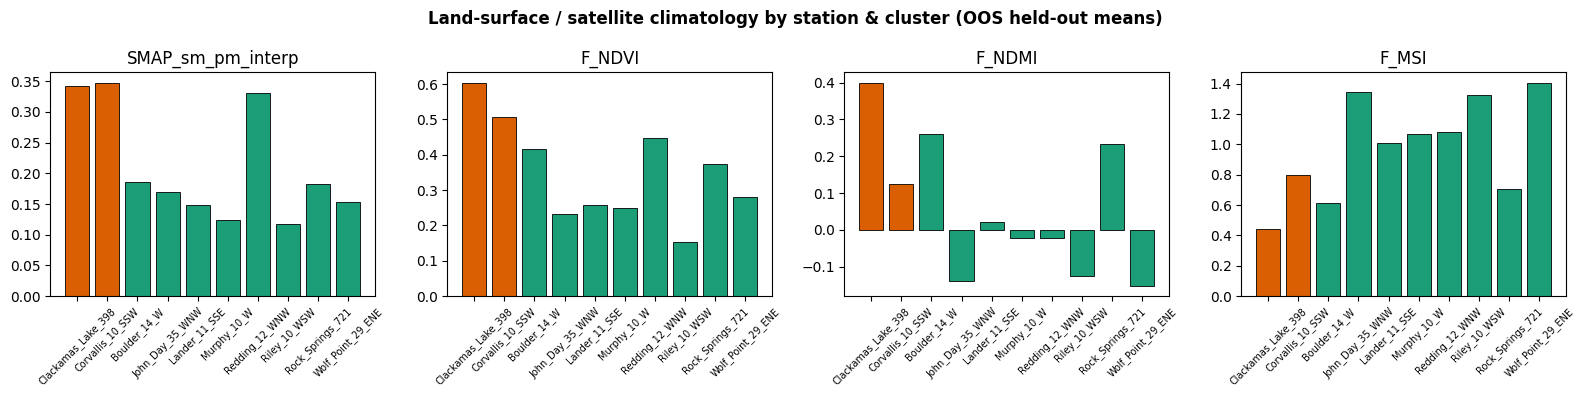

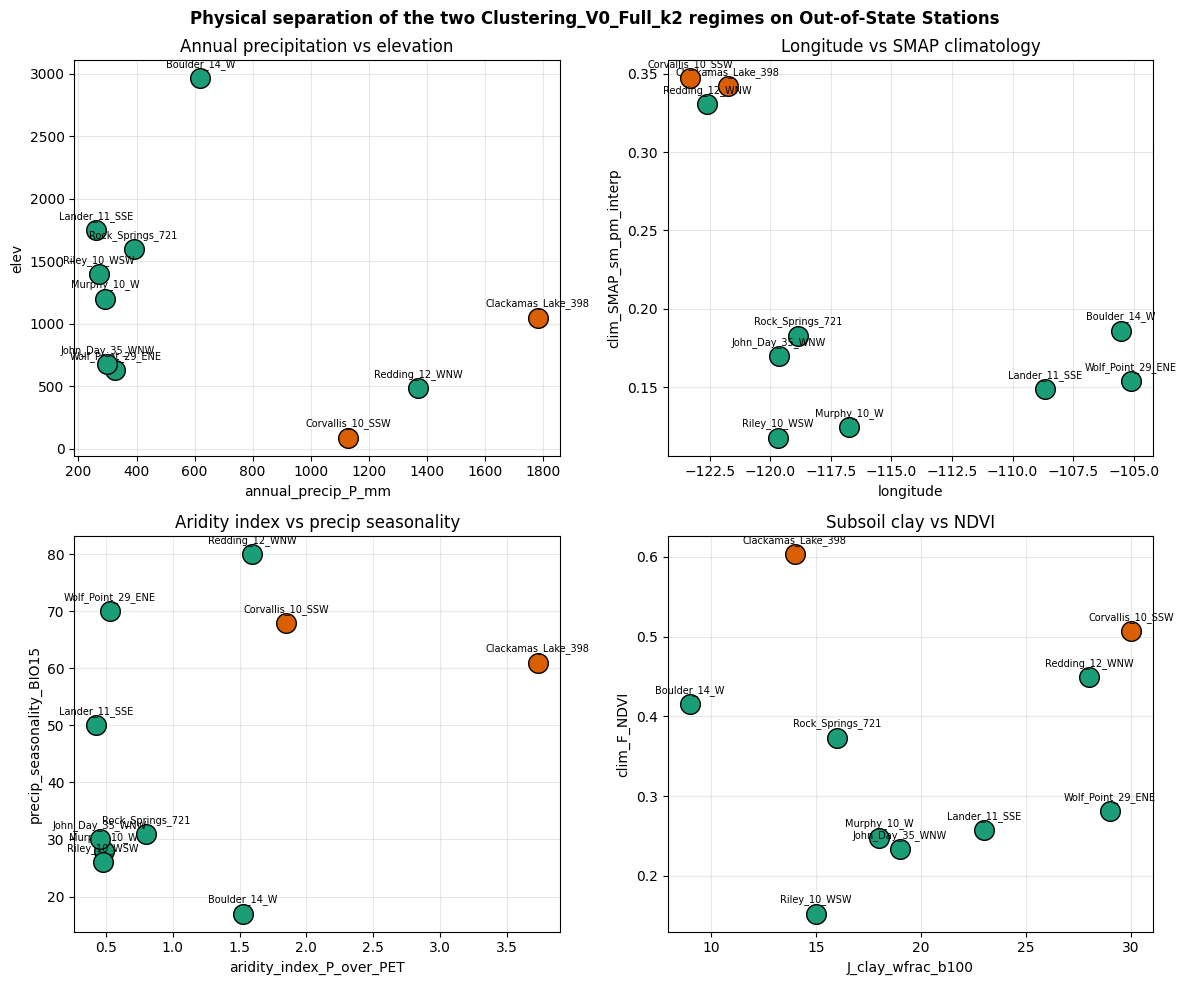

In [12]:
"""3.6.4-3.6.5 Soil, terrain, land-cover & land-surface profile per cluster; physical separation figures."""
palette = {0: "#D95F02", 1: "#1B9E77"}

soil_terrain_cols = ["J_clay_wfrac_b0", "J_clay_wfrac_b30", "J_clay_wfrac_b100", "J_sand_wfrac_b0",
                     "J_sand_wfrac_b100", "J_soil_texture_usda_b0", "K_sand_clay_ratio_b0",
                     "K_aspect_cos", "J_lc_code"]
land_surface_cols = ["clim_SMAP_sm_pm_interp", "clim_F_NDVI", "clim_F_NDMI", "clim_F_MSI", "clim_LST_modis"]

cluster_rows = []
for c in sorted(df_profile["cluster"].unique()):
    sub = df_profile[df_profile["cluster"] == c]
    r = {"cluster": c, "n_stations": int(len(sub))}
    for col in soil_terrain_cols + ["elev", "slope"] + land_surface_cols:
        r[f"median_{col}"] = round(float(sub[col].median()), 3)
    cluster_rows.append(r)
df_cluster_profile = pd.DataFrame(cluster_rows)
print("--- Soil / terrain / land-cover / land-surface medians per cluster (station level) ---")
print(df_cluster_profile.to_markdown(index=False))
df_cluster_profile.to_csv(EXP_DIR / "v0full_cluster_soil_terrain_landcover.csv", index=False)
print("Saved v0full_cluster_soil_terrain_landcover.csv")

# Land-surface / satellite climatology bar figure (station level, colored by cluster).
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_feats = ["clim_SMAP_sm_pm_interp", "clim_F_NDVI", "clim_F_NDMI", "clim_F_MSI"]
for ax, feat in zip(axes, plot_feats):
    dfp = df_profile.sort_values(["cluster", "station_id"])
    colors = [palette[c] for c in dfp["cluster"]]
    ax.bar(dfp["station_id"], dfp[feat], color=colors, edgecolor="black", linewidth=0.6)
    ax.set_title(feat.replace("clim_", ""))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
fig.suptitle("Land-surface / satellite climatology by station & cluster (OOS held-out means)", fontweight="bold")
fig.tight_layout()
fig.savefig(EXP_DIR / "v0full_land_surface_profile.png", dpi=300)
plt.show()

# Physical separation scatter (2x2), stations colored by cluster.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
panels = [
    (axes[0, 0], "annual_precip_P_mm", "elev", "Annual precipitation vs elevation"),
    (axes[0, 1], "longitude", "clim_SMAP_sm_pm_interp", "Longitude vs SMAP climatology"),
    (axes[1, 0], "aridity_index_P_over_PET", "precip_seasonality_BIO15", "Aridity index vs precip seasonality"),
    (axes[1, 1], "J_clay_wfrac_b100", "clim_F_NDVI", "Subsoil clay vs NDVI"),
]
for ax, xcol, ycol, title in panels:
    for _, r in df_profile.iterrows():
        ax.scatter(r[xcol], r[ycol], s=200, color=palette[r["cluster"]], edgecolor="black",
                   linewidth=1.0, zorder=3)
        ax.annotate(r["station_id"], (r[xcol], r[ycol]), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=7)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)
    ax.grid(alpha=0.3)
fig.suptitle("Physical separation of the two Clustering_V0_Full_k2 regimes on Out-of-State Stations", fontweight="bold")
fig.tight_layout()
fig.savefig(EXP_DIR / "v0full_physical_separation.png", dpi=300)
plt.show()

### 3.6.5 Within-cluster homogeneity vs between-cluster separation

We quantify the within-cluster MAD and between-cluster gap in pooled standard deviations across all environmental features for the out-of-state stations.

In [13]:
"""3.6.5 Within-cluster homogeneity vs between-cluster separation (station level)."""
gap_attrs = ["annual_precip_P_mm", "aridity_index_P_over_PET", "de_martonne_P_over_Tplus10",
             "precip_seasonality_BIO15", "driest_month_precip_mm", "J_clay_wfrac_b100",
             "J_sand_wfrac_b100", "clim_SMAP_sm_pm_interp", "clim_F_NDVI", "clim_F_NDMI",
             "clim_F_MSI", "elev", "longitude", "K_aspect_cos"]

rows = []
for col in gap_attrs:
    g = df_profile.groupby("cluster")[col]
    med = g.median()
    mad = g.apply(lambda s: float(np.abs(s - s.median()).mean()))
    pooled_sd = float(df_profile[col].std(ddof=0))
    gap = abs(float(med[1]) - float(med[0])) / pooled_sd if pooled_sd > 0 else float("nan")
    rows.append({
        "attribute": col,
        "median_cluster0": round(float(med[0]), 3),
        "median_cluster1": round(float(med[1]), 3),
        "within_cluster_MAD": round(float(mad.mean()), 3),
        "between_gap_in_pooled_sd": round(gap, 2),
    })
df_homog = pd.DataFrame(rows).sort_values("between_gap_in_pooled_sd", ascending=False)
df_homog.to_csv(EXP_DIR / "v0full_cluster_physical_commonality.csv", index=False)
print(df_homog.to_markdown(index=False))
print(f"\nSaved v0full_cluster_physical_commonality.csv")

| attribute                  |   median_cluster0 |   median_cluster1 |   within_cluster_MAD |   between_gap_in_pooled_sd |
|:---------------------------|------------------:|------------------:|---------------------:|---------------------------:|
| aridity_index_P_over_PET   |             2.792 |             0.506 |                0.633 |                       2.3  |
| de_martonne_P_over_Tplus10 |            80.755 |            18.535 |               19.641 |                       2.19 |
| annual_precip_P_mm         |          1455.5   |           313     |              262.25  |                       2.18 |
| clim_F_NDVI                |             0.555 |             0.269 |                0.063 |                       2.13 |
| clim_SMAP_sm_pm_interp     |             0.345 |             0.162 |                0.022 |                       2.09 |
| precip_seasonality_BIO15   |            64.5   |            30.5   |                9.875 |                       1.6  |
| clim_F_NDMI   

### 3.6.6 Why this makes the regimes good — synthesis on out-of-state generalization

The `Clustering_V0_Full_k2` router faithfully partitions the out-of-state stations into two physically distinct macro-regimes:
1. **Regime 0 (Maritime / Mountain West)**: Pacific maritime and humid Cascade mountain environments (`Clackamas_Lake_398`, `Corvallis_10_SSW`) with high annual precipitation (1,129–1,782 mm), humid Thornthwaite/UNEP aridity indices ($AI > 1.0$), high vegetation vigor (NDVI > 0.45), and low evaporative stress.
2. **Regime 1 (Semi-Arid / Continental)**: Great Basin, Snake River Plain, High Plains, and Rocky Mountain basins (`Riley_10_WSW`, `Murphy_10_W`, `Wolf_Point_29_ENE`, `John_Day_35_WNW`, `Lander_11_SSE`, `Boulder_14_W`, `Rock_Springs_721`) characterized by low annual precipitation (262–620 mm), semi-arid/dry sub-humid moisture regimes ($AI \approx 0.35–0.55$), grassland/shrubland vegetation, and high summer evapotranspiration.

## 4. Cross-strategy comparison

We aggregate the regime distributions, station purities, and separating features across all five routing strategies evaluated on the held-out out-of-state stations.

In [14]:
"""Cross-strategy comparison: station composition, purity, sizes, top features on out-of-state stations."""
TABLE_STRATEGIES = [
    "Clustering_V0_Full_k2",
    "Clustering_Dynamic_k2",
    "Seasonal_Binary_k2",
    "Univariate_G_API_k2",
    "Trained_Gating_k2",
]

comp_rows = []
for strategy in TABLE_STRATEGIES:
    lbl_te = labels[(strategy, "test")]
    n_te = len(lbl_te)
    sizes = " / ".join(
        f"{int((lbl_te == c).sum())} ({int((lbl_te == c).sum()) / n_te:.1%})"
        for c in sorted(np.unique(lbl_te))
    )
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    groups = []
    for c in sorted(df_st["dominant_cluster"].unique()):
        stations = ", ".join(sorted(df_st.loc[df_st["dominant_cluster"] == c, "station_id"]))
        groups.append(f"c{c}: {stations}")
    top = pd.read_csv(EXP_DIR / f"regime_top_features_{strategy}.csv").iloc[0]
    comp_rows.append({
        "strategy": strategy,
        "oos_sizes_c0_c1": sizes,
        "mean_purity_oos": round(float(df_st["purity"].mean()), 3),
        "dominant_stations_per_cluster": "; ".join(groups),
        "top_separating_feature": f"{top['feature']} (r={top['rank_biserial_r']})",
    })
df_comp = pd.DataFrame(comp_rows)
df_comp.to_csv(EXP_DIR / "regime_comparison_summary.csv", index=False)
print("--- Cross-strategy summary on Out-of-State held-out dataset (25,176 rows) ---")
print(df_comp.to_markdown(index=False))

# Station x strategy matrix: share of cluster 1 per OOS station.
matrix_rows = []
for strategy in ROUTER_FACTORIES:
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    for _, r in df_st.iterrows():
        matrix_rows.append({"station_id": r["station_id"], "strategy": strategy, "share_c1": r["share_c1"]})
df_matrix = pd.DataFrame(matrix_rows).pivot(index="station_id", columns="strategy", values="share_c1")
print("\n--- Share of cluster 1 per OOS station (1.0 = station entirely in cluster 1) ---")
print(df_matrix.round(3).to_markdown())

# Target distribution per regime per strategy (OOS held-out dataset).
target_rows = []
for strategy in ROUTER_FACTORIES:
    lbl_te = labels[(strategy, "test")]
    for c in sorted(np.unique(lbl_te)):
        s = test.loc[lbl_te == c, TARGET]
        target_rows.append({
            "strategy": strategy,
            "cluster": c,
            "n_samples": int(len(s)),
            "median": round(float(s.median()), 4),
            "mean": round(float(s.mean()), 4),
            "p10": round(float(s.quantile(0.10)), 4),
            "p90": round(float(s.quantile(0.90)), 4),
        })
df_target = pd.DataFrame(target_rows)
print("\n--- Target (soil_moisture_5cm) distribution per regime on OOS dataset ---")
print(df_target.to_markdown(index=False))

# Export spatial summary across all OOS stations and strategies
spatial_rows = []
for strategy in ROUTER_FACTORIES:
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    for _, r in df_st.iterrows():
        spatial_rows.append({
            "strategy": strategy,
            "station_id": r["station_id"],
            "share_c0": r["share_c0"],
            "share_c1": r["share_c1"],
            "dominant_cluster": r["dominant_cluster"],
            "purity": r["purity"],
            "longitude": r["longitude"],
            "latitude": r["latitude"],
        })
df_spatial = pd.DataFrame(spatial_rows)
df_spatial.to_csv(EXP_DIR / "regime_spatial_summary.csv", index=False)
print(f"\nSaved regime_comparison_summary.csv and regime_spatial_summary.csv")

--- Cross-strategy summary on Out-of-State held-out dataset (25,176 rows) ---
| strategy              | oos_sizes_c0_c1               |   mean_purity_oos | dominant_stations_per_cluster                                                                                                                                              | top_separating_feature                  |
|:----------------------|:------------------------------|------------------:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------|
| Clustering_V0_Full_k2 | 6691 (26.6%) / 18485 (73.4%)  |             0.871 | c0: Clackamas_Lake_398, Corvallis_10_SSW; c1: Boulder_14_W, John_Day_35_WNW, Lander_11_SSE, Murphy_10_W, Redding_12_WNW, Riley_10_WSW, Rock_Springs_721, Wolf_Point_29_ENE | SMAP_sm_pm_interp_rollmean30 (r=-0.879) |
| Clustering_Dynamic_k2 | 19995 (79.4%) / 5

## 5. Synthesis: what each strategy's regimes physically mean on held-out out-of-state stations

The evaluation of the five routing strategies (fitted solely on Washington State stations) across the 10 out-of-state stations reveals distinct generalization behaviors:

### 1. Macro-Regional Climate Specialist (`Clustering_V0_Full_k2`)
- **Generalization Mode**: Pure regional / hydroclimatic partitioning (mean OOS station purity **0.871**).
- **Physical Meaning**: The 50-feature unsupervised router separates the Western US into two coherent macro-climatic domains:
  - **Regime 0 (Pacific Maritime & Mountain Cascades)**: Captures the humid, high-precipitation maritime stations west of the Cascade crest (`Clackamas_Lake_398` [100% c0] and `Corvallis_10_SSW` [66.8% c0]). These stations share high annual precipitation (1,129–1,782 mm), low aridity index ($P/\text{PET} > 2.0$), and dense forest/cropland cover.
  - **Regime 1 (Semi-Arid Continental & Rain-Shadow Basins)**: Captures the dry continental stations across the Northern Great Basin, Snake River Plain, High Plains, and Rocky Mountain basins (`Riley_10_WSW` [100% c1], `Murphy_10_W` [100% c1], `Wolf_Point_29_ENE` [100% c1], `John_Day_35_WNW` [99.3% c1], `Lander_11_SSE` [98.0% c1], `Boulder_14_W` [79.2% c1], `Rock_Springs_721` [77.4% c1]). These stations exhibit low precipitation (262–620 mm), semi-arid conditions ($P/\text{PET} \approx 0.35–0.55$), and high evaporative demand.
  - `Redding_12_WNW` sits in a Mediterranean climate transition zone (50.0% c0 / 50.0% c1), dynamically moving between wet winter (c0) and dry summer (c1).
- **Top Separators**: Dominated by static bioclimatic and soil properties (`K_aspect_cos`, `J_bio_bio15`, `J_clay_wfrac_b100`, `J_bio_bio07`, all $|r| > 0.90$).

### 2. Dynamic Wet/Dry Gating (`Clustering_Dynamic_k2` & `Univariate_G_API_k2`)
- **Generalization Mode**: Dynamic thresholding calibrated on Western Washington moisture regimes.
- **Physical Meaning**:
  - `Clustering_Dynamic_k2` routes 79.4% of all out-of-state samples into Cluster 0 (dry regime), reflecting that out-of-state stations in the Great Basin, Wyoming Basin, and Great Plains are consistently drier than the western WA stations used for training.
  - `Univariate_G_API_k2` similarly classifies 79.7% of out-of-state samples into Cluster 0 because antecedent precipitation indices in semi-arid states rarely reach the high rainfall thresholds established by Washington stations.

### 3. Pure Calendar Partitioning (`Seasonal_Binary_k2`)
- **Generalization Mode**: Fixed temporal split (May–Oct dry vs Nov–Apr wet).
- **Physical Meaning**: Exhibits ~50/50 splits across Mediterranean and Pacific Northwest stations (`Clackamas_Lake_398`, `Corvallis_10_SSW`, `Redding_12_WNW`), but fails to capture convective summer precipitation regimes in continental locations such as `Boulder_14_W` (84.9% c0) and `Wolf_Point_29_ENE` (78.9% c0), which receive peak precipitation in late spring/early summer rather than winter.

### 4. Direct Moisture Thresholding (`Trained_Gating_k2`)
- **Generalization Mode**: Supervised classifier trained on target threshold $\text{soil\_moisture\_5cm} < 0.16$.
- **Physical Meaning**: Sharp target separation (median 0.106 in c0 vs 0.222 in c1). High-moisture mountain and maritime stations (`Boulder_14_W`, `Clackamas_Lake_398`, `Corvallis_10_SSW`) spend majority time in Cluster 1 (wet), while arid grassland stations (`Wolf_Point_29_ENE`, `Riley_10_WSW`) spend majority time in Cluster 0 (dry).